# Proyek Analisis Data: Brazilian E-Commerce Public Dataset (Olist)
- **Oleh:** Chamid Bahrul Ulum
- **Email:** ulumlab@gmail.com


## Deskripsi Dataset

Dataset ini merupakan data publik e-commerce Brazil dari platform Olist yang mencakup periode **September 2016 hingga Oktober 2018**. Dataset terdiri dari 9 tabel relasional yang merepresentasikan seluruh perjalanan transaksi, mulai dari pemesanan hingga ulasan pelanggan.

**Tabel-tabel yang digunakan:**
- `orders_dataset.csv` — informasi status dan waktu pesanan
- `order_items_dataset.csv` — detail item dalam setiap pesanan
- `order_payments_dataset.csv` — metode dan nilai pembayaran
- `order_reviews_dataset.csv` — ulasan dan skor kepuasan pelanggan
- `customers_dataset.csv` — informasi dan lokasi pelanggan
- `products_dataset.csv` — atribut produk
- `product_category_name_translation.csv` — terjemahan nama kategori ke bahasa Inggris
- `sellers_dataset.csv` — informasi dan lokasi penjual
- `geolocation_dataset.csv` — koordinat geografis berdasarkan kode pos

## Menentukan Pertanyaan Bisnis

Berdasarkan konteks dataset e-commerce Olist, berikut adalah pertanyaan bisnis yang dirumuskan menggunakan framework **SMART Question**:

---

**Pertanyaan 1:**
> *Bagaimana tren pertumbuhan revenue bulanan platform Olist dan 10 kategori produk apa yang menghasilkan revenue tertinggi sepanjang periode Januari 2017 hingga Agustus 2018?*

- **Specific**: Fokus pada revenue bulanan dan peringkat kategori produk, bukan sekadar jumlah order.
- **Measurable**: Diukur dari total nilai pembayaran (payment_value) dalam satuan BRL per bulan dan per kategori.
- **Action-Oriented**: Hasil analisis dapat digunakan tim bisnis untuk mengalokasikan anggaran promosi pada kategori dan periode dengan performa terbaik.
- **Relevant**: Revenue adalah metrik inti kesehatan bisnis e-commerce.
- **Time-bound**: Dibatasi pada periode Januari 2017 hingga Agustus 2018 untuk menghindari data yang tidak lengkap di awal dan akhir dataset.

---

**Pertanyaan 2:**
> *Bagaimana distribusi skor ulasan pelanggan (review score 1-5) berdasarkan 10 kategori produk dengan volume order tertinggi, dan kategori apa yang memiliki rata-rata kepuasan terendah sepanjang 2017-2018?*

- **Specific**: Fokus pada hubungan antara kategori produk dan skor kepuasan pelanggan.
- **Measurable**: Diukur dari rata-rata review_score dan distribusi per skor per kategori produk.
- **Action-Oriented**: Kategori dengan kepuasan rendah dapat menjadi prioritas untuk perbaikan kualitas produk atau SLA pengiriman.
- **Relevant**: Kepuasan pelanggan berkorelasi langsung dengan retention rate dan reputasi platform.
- **Time-bound**: Dibatasi pada periode 2017-2018 untuk konsistensi dengan pertanyaan pertama.

## Import Semua Packages/Library yang Digunakan

In [1]:
# [CODE CELL 1]
# Library standar untuk manipulasi dan analisis data
import pandas as pd
import numpy as np

# Library untuk visualisasi data
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Library untuk geospatial analysis
import folium
from folium.plugins import HeatMap

# Library untuk machine learning
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.metrics import (
    silhouette_score, silhouette_samples,
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay
)
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.inspection import permutation_importance

# Library untuk time series decomposition
from statsmodels.tsa.seasonal import seasonal_decompose

# Library untuk tampilan yang lebih baik di notebook
from IPython.display import display, HTML
import warnings
warnings.filterwarnings('ignore')

# Konfigurasi matplotlib
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
plt.rcParams['grid.linestyle'] = '--'

# Palet warna konsisten
COLOR_PRIMARY = '#2E86AB'
COLOR_ACCENT  = '#E84855'
COLOR_NEUTRAL = '#A8A8A8'
COLOR_SUCCESS = '#3BB273'
COLOR_WARNING = '#F4A261'

# Random state untuk reproducibility
RANDOM_STATE = 42

print('Semua library berhasil diimport.')
print(f'Pandas version    : {pd.__version__}')
print(f'NumPy version     : {np.__version__}')
print(f'Scikit-learn OK   : import berhasil')
print(f'Statsmodels OK    : import berhasil')

Semua library berhasil diimport.
Pandas version    : 2.2.2
NumPy version     : 2.0.2
Scikit-learn OK   : import berhasil
Statsmodels OK    : import berhasil


## Data Wrangling

### Gathering Data

Tahap ini bertujuan mengumpulkan dan memuat seluruh data yang dibutuhkan ke dalam format DataFrame. Dataset terdiri dari 9 file CSV yang saling berelasi, mirip dengan skema database relasional.

#### Setup Dataset via Kaggle

Dataset diunduh langsung dari Kaggle menggunakan `kagglehub`. Cara ini lebih praktis daripada upload manual dan memastikan selalu mendapatkan versi terbaru dataset.

**Syarat**: Perlu memiliki akun Kaggle. Saat pertama kali menjalankan sel di bawah di Colab, kamu akan diminta login ke Kaggle melalui popup OAuth (klik link, izinkan akses, salin kode).

In [2]:
# [CODE CELL 2]
# Install kagglehub (biasanya sudah tersedia di Colab, ini memastikan versi terbaru)
!pip install kagglehub -q

import kagglehub
import os

# Mengunduh dataset langsung dari Kaggle
path = kagglehub.dataset_download('olistbr/brazilian-ecommerce')

# Cek isi direktori untuk menemukan nama file yang benar
print(f'Download path: {path}')
print('\nSemua file dalam direktori:')
for root, dirs, files in os.walk(path):
    for fname in sorted(files):
        full = os.path.join(root, fname)
        rel  = os.path.relpath(full, path)
        size_mb = os.path.getsize(full) / (1024 * 1024)
        print(f'  {rel:<60} {size_mb:5.1f} MB')

Using Colab cache for faster access to the 'brazilian-ecommerce' dataset.
Download path: /kaggle/input/brazilian-ecommerce

Semua file dalam direktori:
  olist_customers_dataset.csv                                    8.6 MB
  olist_geolocation_dataset.csv                                 58.4 MB
  olist_order_items_dataset.csv                                 14.7 MB
  olist_order_payments_dataset.csv                               5.5 MB
  olist_order_reviews_dataset.csv                               13.8 MB
  olist_orders_dataset.csv                                      16.8 MB
  olist_products_dataset.csv                                     2.3 MB
  olist_sellers_dataset.csv                                      0.2 MB
  product_category_name_translation.csv                          0.0 MB


In [3]:
# [CODE CELL 3]
# Menentukan DATA_DIR yang benar berdasarkan struktur folder yang ditemukan
# kagglehub kadang menyimpan file langsung di path, kadang di subdirektori

DATA_DIR = path  # default

# Cek apakah file ada di path langsung atau di subdirektori
target_file = 'olist_orders_dataset.csv'

if os.path.exists(os.path.join(path, target_file)):
    DATA_DIR = path
else:
    # Cari di subdirektori
    for root, dirs, files in os.walk(path):
        if target_file in files:
            DATA_DIR = root
            break

print(f'DATA_DIR yang digunakan: {DATA_DIR}')
print(f'Verifikasi file orders  : {os.path.exists(os.path.join(DATA_DIR, target_file))}')

DATA_DIR yang digunakan: /kaggle/input/brazilian-ecommerce
Verifikasi file orders  : True


**Catatan Setup:**
- Dataset berhasil diunduh dari Kaggle menggunakan `kagglehub` tanpa perlu upload manual.
- Seluruh 9 file CSV tersedia di direktori `/kaggle/input/brazilian-ecommerce/` dengan ukuran total ~116 MB.
- Verifikasi file `olist_orders_dataset.csv` berhasil — `DATA_DIR` siap digunakan untuk semua operasi load data selanjutnya.

In [4]:
# [CODE CELL 4]
# Memuat data pesanan sebagai tabel pusat (fact table)
df_orders = pd.read_csv(f'{DATA_DIR}/olist_orders_dataset.csv')

print(f'Shape df_orders: {df_orders.shape}')
display(df_orders.head(3))

Shape df_orders: (99441, 8)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00


#### Load df_orders

In [5]:
# [CODE CELL 5]
# Memuat data item dalam setiap pesanan (harga, seller, produk)
df_order_items = pd.read_csv(f'{DATA_DIR}/olist_order_items_dataset.csv')

print(f'Shape df_order_items: {df_order_items.shape}')
display(df_order_items.head(3))

Shape df_order_items: (112650, 7)


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.9,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.9,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.0,17.87


#### Load df_payments

In [6]:
# [CODE CELL 6]
# Memuat data pembayaran (metode pembayaran dan total nilai transaksi)
df_payments = pd.read_csv(f'{DATA_DIR}/olist_order_payments_dataset.csv')

print(f'Shape df_payments: {df_payments.shape}')
display(df_payments.head(3))

Shape df_payments: (103886, 5)


,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71


#### Load df_reviews

In [7]:
# [CODE CELL 7]
# Memuat data ulasan pelanggan (skor 1-5 dan komentar)
df_reviews = pd.read_csv(f'{DATA_DIR}/olist_order_reviews_dataset.csv')

print(f'Shape df_reviews: {df_reviews.shape}')
display(df_reviews.head(3))

Shape df_reviews: (99224, 7)


,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24


#### Load df_customers

In [8]:
# [CODE CELL 8]
# Memuat data pelanggan (informasi lokasi dan ID unik)
df_customers = pd.read_csv(f'{DATA_DIR}/olist_customers_dataset.csv')

print(f'Shape df_customers: {df_customers.shape}')
display(df_customers.head(3))

Shape df_customers: (99441, 5)


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP


#### Load df_products dan df_category_translation

In [9]:
# [CODE CELL 9]
# Memuat data produk dan terjemahan nama kategori ke bahasa Inggris
df_products    = pd.read_csv(f'{DATA_DIR}/olist_products_dataset.csv')
df_category_en = pd.read_csv(f'{DATA_DIR}/product_category_name_translation.csv')

# Menggabungkan terjemahan kategori ke dalam tabel produk
df_products = df_products.merge(df_category_en, on='product_category_name', how='left')

print(f'Shape df_products: {df_products.shape}')
display(df_products[['product_id', 'product_category_name', 'product_category_name_english']].head(3))

Shape df_products: (32951, 10)


,product_id,product_category_name,product_category_name_english
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,perfumery
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,art
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,sports_leisure


#### Load df_sellers dan df_geolocation

In [10]:
# [CODE CELL 10]
# Memuat data penjual dan geolokasi
df_sellers     = pd.read_csv(f'{DATA_DIR}/olist_sellers_dataset.csv')
df_geolocation = pd.read_csv(f'{DATA_DIR}/olist_geolocation_dataset.csv')

# Mengambil satu koordinat representatif per kode pos (menghindari duplikat)
df_geo_unique = (
    df_geolocation
    .groupby('geolocation_zip_code_prefix')[['geolocation_lat', 'geolocation_lng']]
    .median()
    .reset_index()
)

print(f'Shape df_sellers     : {df_sellers.shape}')
print(f'Shape df_geo_unique  : {df_geo_unique.shape}')
display(df_geo_unique.head(3))

Shape df_sellers     : (3095, 4)
Shape df_geo_unique  : (19015, 3)


,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng
0,1001,-23.550381,-46.634027
1,1002,-23.548551,-46.635072
2,1003,-23.548977,-46.635313


**Insight - Gathering Data:**
- Seluruh 9 tabel dataset berhasil dimuat. Ukuran bervariasi mulai dari 3 KB (`product_category_name_translation.csv`) hingga 58,4 MB (`olist_geolocation_dataset.csv`).
- `olist_orders_dataset.csv` menjadi tabel pusat (fact table) dengan **99.441 baris** dan 8 kolom — mencakup seluruh siklus hidup pesanan dari pembuatan hingga pengiriman.
- `olist_geolocation_dataset.csv` memiliki banyak entri duplikat per kode pos (total file 58,4 MB), sehingga diambil nilai **median koordinat** per kode pos unik menghasilkan 19.015 entri representatif.
- Nama kategori produk asli berbahasa Portugis, sudah berhasil digabungkan dengan tabel terjemahan bahasa Inggris (`product_category_name_translation.csv`) ke dalam `df_products`.

### Assessing Data

Tahap ini bertujuan menilai kualitas data sebelum digunakan untuk analisis. Kita akan mengidentifikasi berbagai masalah potensial seperti missing values, tipe data yang tidak sesuai, duplikat, dan nilai yang tidak konsisten.

#### Mengidentifikasi Missing Value pada Tabel Utama

In [11]:
# [CODE CELL 11]
# Fungsi bantu untuk merangkum missing values sebuah DataFrame
def summarize_missing(df, name):
    missing = df.isnull().sum()
    missing_pct = (missing / len(df) * 100).round(2)
    summary = pd.DataFrame({
        'Missing Count': missing,
        'Missing (%)': missing_pct
    })
    summary = summary[summary['Missing Count'] > 0].sort_values('Missing (%)', ascending=False)
    print(f'\n=== Missing Values: {name} ===')
    if summary.empty:
        print('Tidak ada missing value.')
    else:
        display(summary)

# Periksa missing values pada setiap tabel utama
summarize_missing(df_orders,      'df_orders')
summarize_missing(df_order_items, 'df_order_items')
summarize_missing(df_payments,    'df_payments')
summarize_missing(df_reviews,     'df_reviews')
summarize_missing(df_customers,   'df_customers')
summarize_missing(df_products,    'df_products')


=== Missing Values: df_orders ===


,Missing Count,Missing (%)
order_delivered_customer_date,2965,2.98
order_delivered_carrier_date,1783,1.79
order_approved_at,160,0.16



=== Missing Values: df_order_items ===
Tidak ada missing value.

=== Missing Values: df_payments ===
Tidak ada missing value.

=== Missing Values: df_reviews ===


,Missing Count,Missing (%)
review_comment_title,87656,88.34
review_comment_message,58247,58.70



=== Missing Values: df_customers ===
Tidak ada missing value.

=== Missing Values: df_products ===


,Missing Count,Missing (%)
product_category_name_english,623,1.89
product_category_name,610,1.85
product_name_lenght,610,1.85
product_photos_qty,610,1.85
product_description_lenght,610,1.85
product_weight_g,2,0.01
product_length_cm,2,0.01
product_height_cm,2,0.01
product_width_cm,2,0.01


#### Mengidentifikasi Masalah Tipe Data

In [12]:
# [CODE CELL 12]
# Memeriksa tipe data kolom-kolom timestamp di df_orders
# Kolom tanggal seharusnya bertipe datetime, bukan object (string)
print('Tipe data df_orders:')
print(df_orders.dtypes)

# Contoh nilai kolom timestamp untuk memverifikasi format
print('\nContoh nilai order_purchase_timestamp:')
print(df_orders['order_purchase_timestamp'].head())

Tipe data df_orders:
order_id                         object
customer_id                      object
order_status                     object
order_purchase_timestamp         object
order_approved_at                object
order_delivered_carrier_date     object
order_delivered_customer_date    object
order_estimated_delivery_date    object
dtype: object

Contoh nilai order_purchase_timestamp:
0    2017-10-02 10:56:33
1    2018-07-24 20:41:37
2    2018-08-08 08:38:49
3    2017-11-18 19:28:06
4    2018-02-13 21:18:39
Name: order_purchase_timestamp, dtype: object


#### Mengidentifikasi Duplikat

In [13]:
# [CODE CELL 13]
# Memeriksa duplikat pada primary key setiap tabel utama
tables_to_check = {
    'df_orders'      : (df_orders,      'order_id'),
    'df_customers'   : (df_customers,   'customer_id'),
    'df_products'    : (df_products,    'product_id'),
    'df_sellers'     : (df_sellers,     'seller_id'),
}

for name, (df, key_col) in tables_to_check.items():
    n_dup = df.duplicated(subset=[key_col]).sum()
    status = 'OK' if n_dup == 0 else f'PERHATIAN: {n_dup} duplikat'
    print(f'{name:<20} [{key_col}]: {status}')

# Tabel order_reviews bisa memiliki multiple reviews per order, ini valid
n_dup_reviews = df_reviews.duplicated(subset=['order_id', 'review_id']).sum()
print(f'df_reviews           [order_id+review_id]: {n_dup_reviews} duplikat')

df_orders            [order_id]: OK
df_customers         [customer_id]: OK
df_products          [product_id]: OK
df_sellers           [seller_id]: OK
df_reviews           [order_id+review_id]: 0 duplikat


#### Mengidentifikasi Invalid Value pada Status Order

In [14]:
# [CODE CELL 14]
# Memeriksa distribusi nilai unik pada kolom status order
# Hanya pesanan dengan status 'delivered' yang valid untuk analisis revenue dan kepuasan
print('Distribusi order_status:')
status_counts = df_orders['order_status'].value_counts()
print(status_counts)

# Persentase status yang bukan 'delivered'
non_delivered = df_orders[df_orders['order_status'] != 'delivered'].shape[0]
pct_non_delivered = non_delivered / len(df_orders) * 100
print(f'\nPesanan bukan delivered: {non_delivered:,} ({pct_non_delivered:.2f}%)')

Distribusi order_status:
order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

Pesanan bukan delivered: 2,963 (2.98%)


#### Mengidentifikasi Outlier pada Payment Value

In [15]:
# [CODE CELL 15]
# Memeriksa statistik deskriptif payment_value untuk mendeteksi outlier ekstrem
payment_per_order = df_payments.groupby('order_id')['payment_value'].sum().reset_index()
payment_per_order.columns = ['order_id', 'total_payment']

print('Statistik deskriptif total_payment per order:')
print(payment_per_order['total_payment'].describe().round(2))

# Deteksi outlier menggunakan metode IQR
Q1  = payment_per_order['total_payment'].quantile(0.25)
Q3  = payment_per_order['total_payment'].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 3 * IQR  # Menggunakan 3x IQR untuk outlier ekstrem

n_outlier = (payment_per_order['total_payment'] > upper_bound).sum()
print(f'\nBatas outlier ekstrem (Q3 + 3*IQR): BRL {upper_bound:,.2f}')
print(f'Jumlah outlier ekstrem: {n_outlier} orders ({n_outlier/len(payment_per_order)*100:.2f}%)')

Statistik deskriptif total_payment per order:
count    99440.00
mean       160.99
std        221.95
min          0.00
25%         62.01
50%        105.29
75%        176.97
max      13664.08
Name: total_payment, dtype: float64

Batas outlier ekstrem (Q3 + 3*IQR): BRL 521.85
Jumlah outlier ekstrem: 3999 orders (4.02%)


**Steps to Take (Cleaning Plan):**
1. **Konversi tipe data timestamp**: Semua 5 kolom timestamp di `df_orders` bertipe `object` (string), perlu dikonversi ke `datetime64` agar bisa dilakukan operasi aritmatika tanggal.
2. **Filter status order**: Dari 99.441 pesanan, terdapat **2.963 pesanan (2,98%) bukan berstatus `delivered`** (shipped, canceled, unavailable, dll). Pesanan ini tidak valid untuk analisis revenue dan kepuasan, sehingga akan dihapus.
3. **Imputasi missing value di `df_products`**: Kolom `product_category_name` dan `product_category_name_english` yang null akan diisi dengan label `'unknown'` agar produk tetap terhitung dan tidak hilang dari analisis.
4. **Penanganan missing value di `df_reviews`**: Kolom `review_comment_title` (88,34% null) dan `review_comment_message` (58,70% null) dibiarkan apa adanya — kolom ini bersifat opsional dan tidak digunakan dalam analisis kuantitatif.
5. **Deduplikasi `df_reviews`**: Dari 99.224 review, terdapat **551 duplikat** (satu order memiliki lebih dari satu review). Untuk setiap order, hanya dipertahankan satu review terbaru berdasarkan `review_creation_date`.
6. **Filter rentang waktu analisis**: Batasi data pada periode **Januari 2017 – Agustus 2018** untuk memastikan data bulan penuh dan representatif, menghindari data di awal (2016) yang sangat sedikit.

### Cleaning Data

Berdasarkan temuan pada tahap Assessing Data, berikut adalah langkah-langkah pembersihan data yang akan dilakukan secara sistematis.

#### Konversi Tipe Data Timestamp

In [16]:
# [CODE CELL 16]
# Daftar kolom yang perlu dikonversi ke tipe datetime
timestamp_cols = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]

for col in timestamp_cols:
    df_orders[col] = pd.to_datetime(df_orders[col], errors='coerce')

# Verifikasi tipe data setelah konversi
print('Tipe data setelah konversi:')
print(df_orders[timestamp_cols].dtypes)

Tipe data setelah konversi:
order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_delivered_carrier_date     datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
dtype: object


#### Filter Status Order

In [17]:
# [CODE CELL 17]
# Hanya mempertahankan pesanan yang statusnya 'delivered'
# Pesanan yang dibatalkan, sedang diproses, atau dikembalikan tidak valid untuk analisis revenue
df_orders_clean = df_orders[df_orders['order_status'] == 'delivered'].copy()

print(f'Jumlah order sebelum filter : {len(df_orders):,}')
print(f'Jumlah order setelah filter : {len(df_orders_clean):,}')
print(f'Order yang dihapus          : {len(df_orders) - len(df_orders_clean):,}')

Jumlah order sebelum filter : 99,441
Jumlah order setelah filter : 96,478
Order yang dihapus          : 2,963


#### Imputasi Missing Value pada df_products

In [18]:
# [CODE CELL 18]
# Mengisi nama kategori yang kosong dengan label 'unknown'
# Produk tanpa kategori tetap dimasukkan agar tidak ada bias penghapusan data
df_products['product_category_name'].fillna('unknown', inplace=True)
df_products['product_category_name_english'].fillna('unknown', inplace=True)

# Verifikasi
remaining_null = df_products[['product_category_name', 'product_category_name_english']].isnull().sum()
print('Missing value setelah imputasi:')
print(remaining_null)

Missing value setelah imputasi:
product_category_name            0
product_category_name_english    0
dtype: int64


#### Hapus Duplikat pada df_reviews

In [19]:
# [CODE CELL 19]
# Untuk setiap order, ambil satu review terbaru (berdasarkan review_creation_date)
df_reviews['review_creation_date'] = pd.to_datetime(df_reviews['review_creation_date'], errors='coerce')

df_reviews_clean = (
    df_reviews
    .sort_values('review_creation_date', ascending=False)
    .drop_duplicates(subset=['order_id'], keep='first')
    .reset_index(drop=True)
)

print(f'Jumlah reviews sebelum deduplicate : {len(df_reviews):,}')
print(f'Jumlah reviews setelah deduplicate : {len(df_reviews_clean):,}')

Jumlah reviews sebelum deduplicate : 99,224
Jumlah reviews setelah deduplicate : 98,673


#### Membuat Master DataFrame untuk Analisis

In [20]:
# [CODE CELL 20]
# Menggabungkan semua tabel menjadi satu master DataFrame
# Menggunakan left join dari orders_clean sebagai basis agar tidak kehilangan data

# Langkah 1: Gabungkan order dengan data pelanggan
df_main = df_orders_clean.merge(df_customers[['customer_id', 'customer_unique_id',
                                              'customer_city', 'customer_state',
                                              'customer_zip_code_prefix']],
                                on='customer_id', how='left')

# Langkah 2: Gabungkan dengan total pembayaran per order
payment_per_order = (
    df_payments
    .groupby('order_id')['payment_value']
    .sum()
    .reset_index()
    .rename(columns={'payment_value': 'total_payment'})
)
df_main = df_main.merge(payment_per_order, on='order_id', how='left')

# Langkah 3: Gabungkan dengan review score (rata-rata jika ada lebih dari satu)
df_main = df_main.merge(
    df_reviews_clean[['order_id', 'review_score']],
    on='order_id', how='left'
)

# Langkah 4: Gabungkan dengan item detail dan nama kategori
# Agregasi: ambil kategori produk pertama & total harga item per order
item_agg = (
    df_order_items
    .merge(df_products[['product_id', 'product_category_name_english']],
           on='product_id', how='left')
    .groupby('order_id')
    .agg(
        total_item_price   = ('price', 'sum'),
        total_freight      = ('freight_value', 'sum'),
        product_category   = ('product_category_name_english', 'first'),
        n_items            = ('order_item_id', 'count')
    )
    .reset_index()
)
df_main = df_main.merge(item_agg, on='order_id', how='left')

# Langkah 5: Tambahkan kolom waktu yang berguna
df_main['purchase_year']      = df_main['order_purchase_timestamp'].dt.year
df_main['purchase_month']     = df_main['order_purchase_timestamp'].dt.month
df_main['purchase_yearmonth'] = df_main['order_purchase_timestamp'].dt.to_period('M')

# Langkah 6: Filter rentang waktu analisis (Januari 2017 - Agustus 2018)
df_main = df_main[
    (df_main['order_purchase_timestamp'] >= '2017-01-01') &
    (df_main['order_purchase_timestamp'] <= '2018-08-31')
].copy()

print(f'Shape master DataFrame : {df_main.shape}')
print(f'Rentang waktu          : {df_main["order_purchase_timestamp"].min().date()} s/d {df_main["order_purchase_timestamp"].max().date()}')
display(df_main.head(3))

Shape master DataFrame : (96211, 21)
Rentang waktu          : 2017-01-05 s/d 2018-08-29


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_city,...,customer_zip_code_prefix,total_payment,review_score,total_item_price,total_freight,product_category,n_items,purchase_year,purchase_month,purchase_yearmonth
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,sao paulo,...,3149,38.71,4.0,29.99,8.72,housewares,1,2017,10,2017-10
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,barreiras,...,47813,141.46,4.0,118.70,22.76,perfumery,1,2018,7,2018-07
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,vianopolis,...,75265,179.12,5.0,159.90,19.22,auto,1,2018,8,2018-08


**Insight - Data Wrangling:**
- Seluruh 5 kolom timestamp berhasil dikonversi dari `object` ke `datetime64[ns]` tanpa nilai yang gagal dikonversi.
- Setelah filter status `delivered`, tersisa **96.478 pesanan** dari 99.441 (menghapus 2.963 pesanan atau 2,98%).
- Proses deduplikasi review menghasilkan pengurangan dari 99.224 menjadi **98.673 review bersih** (551 duplikat dihapus).
- Master DataFrame final berisi **96.211 baris** (rentang waktu analisis: **Januari 2017 – Agustus 2018**) dengan 21 kolom. Perbedaan dengan periode dataset asli (September 2016–Oktober 2018) karena order sebelum Januari 2017 tidak memiliki data review/payment lengkap setelah proses filter `delivered` dan join antar tabel yang mencakup seluruh dimensi analisis: waktu, pelanggan, produk, pembayaran, dan kepuasan.

## Exploratory Data Analysis (EDA)

Pada tahap ini, kita akan mengeksplorasi data secara mendalam untuk menemukan pola, tren, dan anomali yang relevan dengan pertanyaan bisnis yang telah dirumuskan.

### Explore Tren Revenue Bulanan (Pertanyaan 1)

In [21]:
# [CODE CELL 21]
# Menghitung total revenue per bulan
monthly_revenue = (
    df_main
    .groupby('purchase_yearmonth')['total_payment']
    .sum()
    .reset_index()
)
monthly_revenue.columns = ['yearmonth', 'revenue']
monthly_revenue['yearmonth_str'] = monthly_revenue['yearmonth'].astype(str)

# Statistik ringkasan revenue bulanan
print('Statistik revenue bulanan (BRL):')
print(monthly_revenue['revenue'].describe().round(0))

# Bulan dengan revenue tertinggi dan terendah
print(f'\nBulan dengan revenue tertinggi : {monthly_revenue.loc[monthly_revenue["revenue"].idxmax(), "yearmonth_str"]} - BRL {monthly_revenue["revenue"].max():,.0f}')
print(f'Bulan dengan revenue terendah  : {monthly_revenue.loc[monthly_revenue["revenue"].idxmin(), "yearmonth_str"]} - BRL {monthly_revenue["revenue"].min():,.0f}')

Statistik revenue bulanan (BRL):
count         20.0
mean      768794.0
std       320710.0
min       127546.0
25%       547359.0
50%       797170.0
75%      1040580.0
max      1153528.0
Name: revenue, dtype: float64

Bulan dengan revenue tertinggi : 2017-11 - BRL 1,153,528
Bulan dengan revenue terendah  : 2017-01 - BRL 127,546


### Explore Revenue per Kategori Produk

In [22]:
# [CODE CELL 22]
# Menghitung total revenue dan jumlah order per kategori produk
category_revenue = (
    df_main[df_main['product_category'] != 'unknown']
    .groupby('product_category')
    .agg(
        total_revenue = ('total_payment', 'sum'),
        n_orders      = ('order_id', 'count'),
        avg_review    = ('review_score', 'mean')
    )
    .reset_index()
    .sort_values('total_revenue', ascending=False)
)

# Menampilkan 10 kategori teratas
print('Top 10 kategori berdasarkan total revenue:')
display(category_revenue.head(10)[['product_category', 'total_revenue', 'n_orders', 'avg_review']]
        .assign(total_revenue=lambda x: x['total_revenue'].map('BRL {:,.0f}'.format),
                avg_review=lambda x: x['avg_review'].round(2)))

Top 10 kategori berdasarkan total revenue:


,product_category,total_revenue,n_orders,avg_review
43,health_beauty,"BRL 1,406,712",8571,4.24
70,watches_gifts,"BRL 1,259,157",5468,4.13
7,bed_bath_table,"BRL 1,223,393",9162,4.01
65,sports_leisure,"BRL 1,116,864",7474,4.23
15,computers_accessories,"BRL 1,029,991",6489,4.08
39,furniture_decor,"BRL 877,672",6166,4.07
49,housewares,"BRL 759,226",5679,4.21
20,cool_stuff,"BRL 691,758",3523,4.23
5,auto,"BRL 668,022",3785,4.15
42,garden_tools,"BRL 566,141",3409,4.19


### Explore Distribusi Review Score (Pertanyaan 2)

In [23]:
# [CODE CELL 23]
# Distribusi keseluruhan review score
print('Distribusi keseluruhan review score:')
score_dist = df_main['review_score'].value_counts().sort_index()
print(score_dist)
print(f'\nRata-rata review score keseluruhan : {df_main["review_score"].mean():.3f}')
print(f'Proporsi score 5 (sangat puas)     : {(df_main["review_score"]==5).sum()/df_main["review_score"].notna().sum()*100:.1f}%')
print(f'Proporsi score 1 (sangat tidak puas): {(df_main["review_score"]==1).sum()/df_main["review_score"].notna().sum()*100:.1f}%')

Distribusi keseluruhan review score:
review_score
1.0     9314
2.0     2914
3.0     7895
4.0    18843
5.0    56602
Name: count, dtype: int64

Rata-rata review score keseluruhan : 4.156
Proporsi score 5 (sangat puas)     : 59.2%
Proporsi score 1 (sangat tidak puas): 9.7%


### Explore Kepuasan per Kategori Produk

In [24]:
# [CODE CELL 24]
# Mengambil 10 kategori produk dengan volume order terbanyak
top10_categories = (
    df_main[df_main['product_category'] != 'unknown']
    .groupby('product_category')['order_id']
    .count()
    .nlargest(10)
    .index
    .tolist()
)

# Filter data untuk 10 kategori tersebut
df_top10 = df_main[
    (df_main['product_category'].isin(top10_categories)) &
    (df_main['review_score'].notna())
].copy()

# Menghitung rata-rata review score per kategori (diurutkan dari terendah)
category_score = (
    df_top10
    .groupby('product_category')['review_score']
    .agg(['mean', 'count', 'std'])
    .round(3)
    .sort_values('mean', ascending=True)
    .reset_index()
)

print('Rata-rata review score per kategori (urutan terendah ke tertinggi):')
display(category_score)

Rata-rata review score per kategori (urutan terendah ke tertinggi):


,product_category,mean,count,std
0,bed_bath_table,4.010,9067,1.364
1,telephony,4.056,4045,1.309
2,furniture_decor,4.074,6121,1.348
3,computers_accessories,4.084,6458,1.335
4,watches_gifts,4.127,5428,1.309
5,auto,4.152,3767,1.278
6,housewares,4.205,5646,1.239
7,sports_leisure,4.233,7430,1.236
8,health_beauty,4.238,8525,1.241
9,toys,4.241,3728,1.243


**Insight - EDA:**
- Revenue bulanan menunjukkan pertumbuhan yang nyata: dari BRL 127.546 pada Januari 2017 (terendah) melonjak hingga **BRL 1.153.528 pada November 2017** (tertinggi) — hampir 9x lipat dalam 10 bulan. Setelah November 2017 terjadi penurunan dan kemudian stabil di kisaran BRL 800 ribu – 1 juta sepanjang 2018.
- Kategori **`health_beauty`** memimpin dengan total revenue **BRL 1.406.712** dari 8.571 order, diikuti `watches_gifts` (BRL 1.259.157) dan `bed_bath_table` (BRL 1.223.393).
- Rata-rata review score keseluruhan adalah **4,156 dari 5,0** — cukup tinggi. Sebesar **59,2% pelanggan memberikan skor 5** (sangat puas), namun **9,7% memberikan skor 1** (sangat tidak puas) — kelompok ini perlu diidentifikasi penyebabnya.
- Dari 10 kategori dengan volume order tertinggi, **`bed_bath_table`** memiliki rata-rata skor terendah (4,010) diikuti **`telephony`** (4,056). Sementara **`toys`** dan **`health_beauty`** memiliki kepuasan tertinggi (4,241 dan 4,238).

### EDA Lanjutan: Analisis Distribusi, Normalitas, dan Hubungan Antar Variabel

Bagian ini melengkapi EDA dasar dengan analisis yang lebih mendalam meliputi:
1. **Analisis Distribusi Univariat** — Histogram, KDE Plot, Boxplot, Skewness & Kurtosis
2. **Uji Normalitas** — Q-Q Plot dan Shapiro-Wilk Test
3. **Analisis Multivariat** — Pairplot dan Correlation Matrix
4. **Analisis Kategorikal** — Violin Plot dan Chi-Square Test

Hasil analisis ini menjadi **dasar pemilihan metode statistik** pada analisis lanjutan:
- Karena data tidak berdistribusi normal → dipilih **Spearman** (bukan Pearson) untuk korelasi
- Karena terdapat outlier signifikan → dipilih **Random Forest** (bukan Logistic Regression)
- Karena data kategorikal memiliki hubungan signifikan → analisis RFM dan clustering relevan

#### EDA Lanjutan 1: Distribusi Univariat — Histogram, KDE, Skewness & Kurtosis

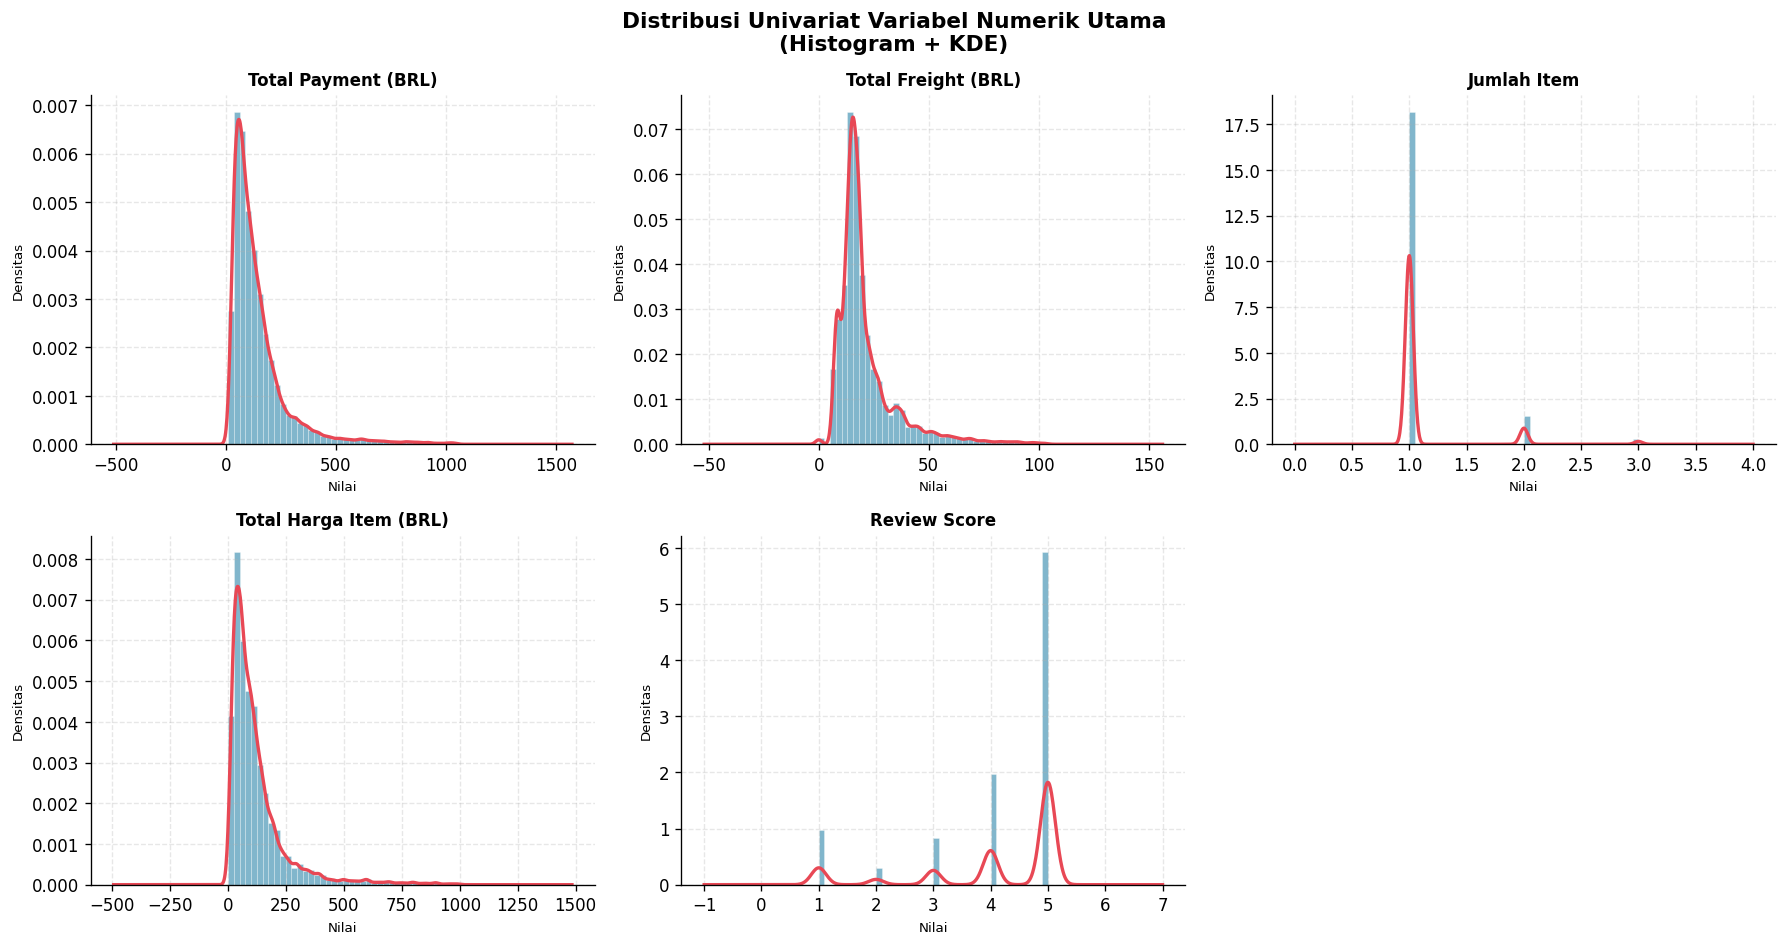

=== Skewness & Kurtosis Variabel Numerik ===
                  Skewness  Kurtosis Interpretasi Skewness
total_payment        9.379   249.573     Positively Skewed
total_freight       12.293   586.934     Positively Skewed
n_items              7.570   116.761     Positively Skewed
total_item_price     9.898   277.406     Positively Skewed
review_score        -1.484     0.962     Negatively Skewed

Catatan:
  |Skewness| < 0.5  : Distribusi mendekati simetris/normal
  |Skewness| > 0.5  : Distribusi condong (skewed)
  Kurtosis > 3      : Heavy-tailed (leptokurtic)
  Kurtosis < 3      : Light-tailed (platykurtic)


In [25]:
# [CODE CELL 25]
# Analisis distribusi univariat untuk semua variabel numerik utama
# Histogram + KDE memberikan gambaran bentuk distribusi secara visual
num_cols = ['total_payment', 'total_freight', 'n_items', 'total_item_price', 'review_score']
col_labels = {
    'total_payment': 'Total Payment (BRL)',
    'total_freight': 'Total Freight (BRL)',
    'n_items': 'Jumlah Item',
    'total_item_price': 'Total Harga Item (BRL)',
    'review_score': 'Review Score'
}

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Distribusi Univariat Variabel Numerik Utama\n(Histogram + KDE)',
             fontsize=13, fontweight='bold')
axes = axes.flatten()

for idx, col in enumerate(num_cols):
    ax = axes[idx]
    data = df_main[col].dropna()
    # Clip outlier ekstrem untuk visualisasi yang lebih jelas
    p99 = data.quantile(0.99)
    data_clipped = data[data <= p99]
    ax.hist(data_clipped, bins=40, color='#2E86AB', alpha=0.6,
            density=True, edgecolor='white', linewidth=0.3)
    data_clipped.plot.kde(ax=ax, color='#E84855', lw=2)
    ax.set_title(col_labels[col], fontsize=10, fontweight='bold')
    ax.set_xlabel('Nilai', fontsize=8)
    ax.set_ylabel('Densitas', fontsize=8)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

axes[-1].set_visible(False)
plt.tight_layout()
plt.savefig('viz_histogram_kde.png', dpi=150, bbox_inches='tight')
plt.show()

# Skewness dan Kurtosis
print('=== Skewness & Kurtosis Variabel Numerik ===')
sk_df = pd.DataFrame({
    'Skewness': df_main[num_cols].skew(),
    'Kurtosis': df_main[num_cols].kurtosis()
}).round(3)
sk_df['Interpretasi Skewness'] = sk_df['Skewness'].apply(
    lambda x: 'Simetris' if abs(x) < 0.5 else
              'Positively Skewed' if x > 0 else 'Negatively Skewed'
)
print(sk_df.to_string())
print('\nCatatan:')
print('  |Skewness| < 0.5  : Distribusi mendekati simetris/normal')
print('  |Skewness| > 0.5  : Distribusi condong (skewed)')
print('  Kurtosis > 3      : Heavy-tailed (leptokurtic)')
print('  Kurtosis < 3      : Light-tailed (platykurtic)')


#### EDA Lanjutan 2: Boxplot Univariat — Deteksi Outlier per Variabel

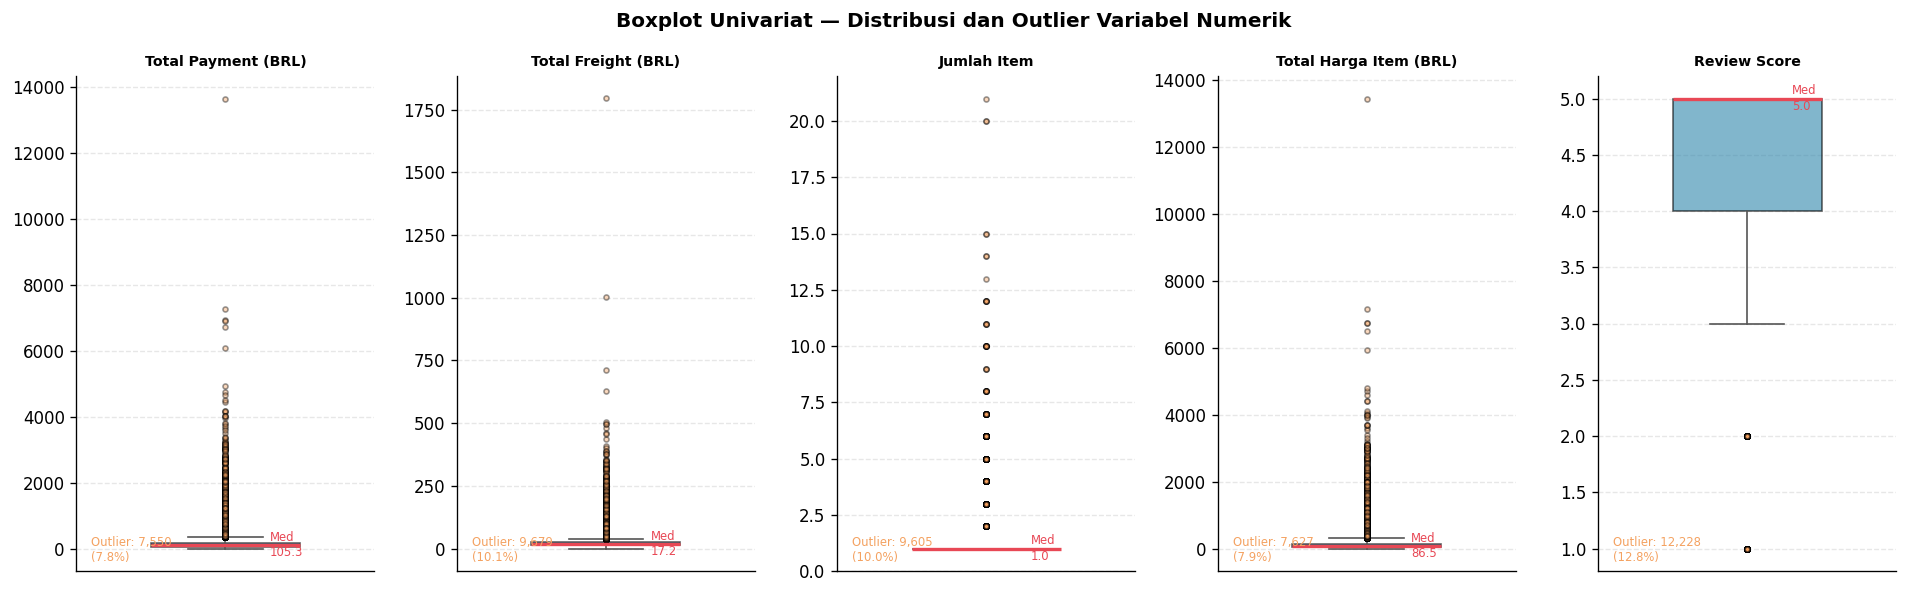

=== Ringkasan Outlier (Metode IQR) ===
  total_payment       : 7,550 outlier (7.8%)
  total_freight       : 9,679 outlier (10.1%)
  n_items             : 9,605 outlier (10.0%)
  total_item_price    : 7,627 outlier (7.9%)
  review_score        : 12,228 outlier (12.8%)


In [26]:
# [CODE CELL 26]
# Boxplot univariat untuk mendeteksi outlier secara sistematis
# Boxplot menampilkan Q1, median, Q3, whisker, dan outlier
fig, axes = plt.subplots(1, 5, figsize=(16, 5))
fig.suptitle('Boxplot Univariat — Distribusi dan Outlier Variabel Numerik',
             fontsize=12, fontweight='bold')

for idx, col in enumerate(num_cols):
    ax = axes[idx]
    data = df_main[col].dropna()
    bp = ax.boxplot(data, patch_artist=True, widths=0.5,
                    boxprops=dict(facecolor='#2E86AB', alpha=0.6),
                    medianprops=dict(color='#E84855', linewidth=2),
                    whiskerprops=dict(color='#555'),
                    capprops=dict(color='#555'),
                    flierprops=dict(marker='o', markerfacecolor='#F4A261',
                                   markersize=3, alpha=0.4))
    ax.set_title(col_labels[col], fontsize=8.5, fontweight='bold')
    ax.set_xticks([])
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    # Anotasi statistik
    q1, med, q3 = data.quantile([0.25, 0.5, 0.75])
    n_outliers = ((data < q1 - 1.5*(q3-q1)) | (data > q3 + 1.5*(q3-q1))).sum()
    ax.text(1.15, med, f'Med\n{med:.1f}', fontsize=7, va='center', color='#E84855')
    ax.text(0.05, 0.02, f'Outlier: {n_outliers:,}\n({n_outliers/len(data)*100:.1f}%)',
            transform=ax.transAxes, fontsize=7, color='#F4A261')

plt.tight_layout()
plt.savefig('viz_boxplot_univariate.png', dpi=150, bbox_inches='tight')
plt.show()

# Ringkasan outlier
print('=== Ringkasan Outlier (Metode IQR) ===')
for col in num_cols:
    d = df_main[col].dropna()
    q1, q3 = d.quantile(0.25), d.quantile(0.75)
    iqr = q3 - q1
    n_out = ((d < q1 - 1.5*iqr) | (d > q3 + 1.5*iqr)).sum()
    print(f'  {col:<20}: {n_out:>5,} outlier ({n_out/len(d)*100:.1f}%)')


#### EDA Lanjutan 3: Uji Normalitas — Q-Q Plot dan Shapiro-Wilk Test

Uji normalitas penting sebagai **dasar pemilihan metode statistik**:
- Jika data normal → bisa menggunakan Pearson correlation, ANOVA, t-test
- Jika data tidak normal → gunakan Spearman correlation, Kruskal-Wallis, Mann-Whitney

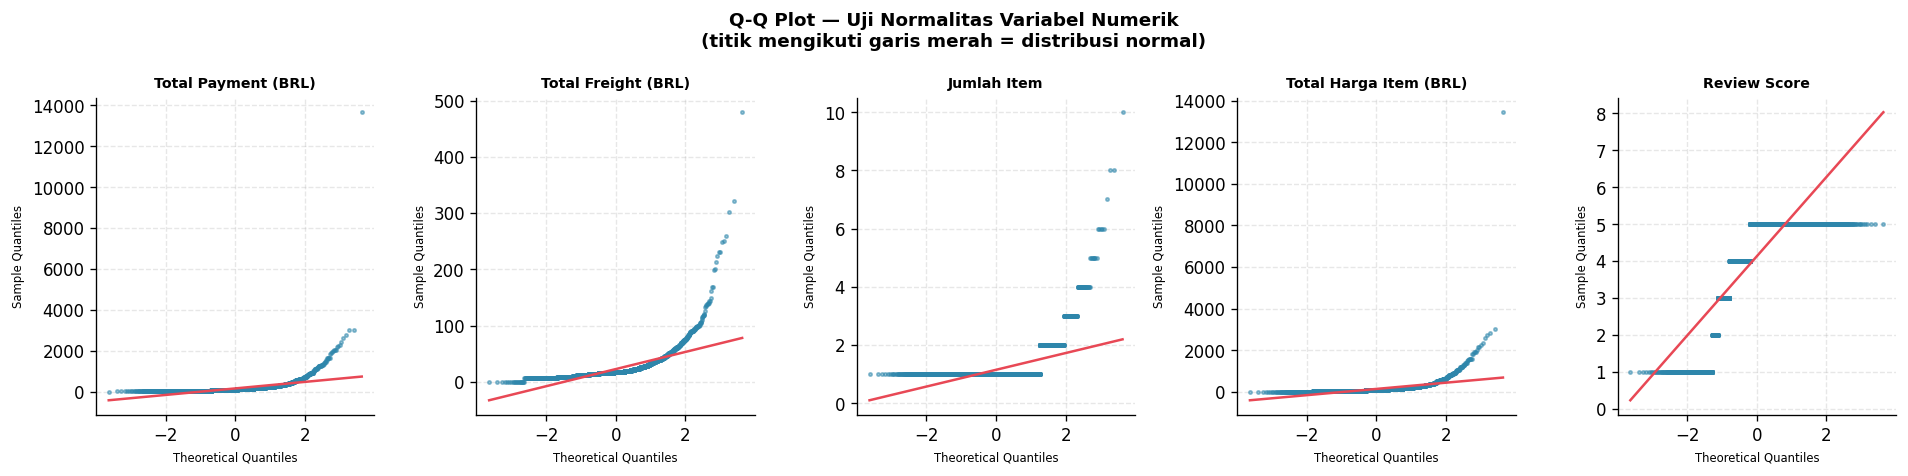

=== Shapiro-Wilk Normality Test (sample n=5000) ===
Variabel                W-Statistic      p-value    Normal?
------------------------------------------------------------
total_payment                0.3196     0.000000 Tidak (p<0.05)
total_freight                0.5462     0.000000 Tidak (p<0.05)
n_items                      0.3076     0.000000 Tidak (p<0.05)
total_item_price             0.3025     0.000000 Tidak (p<0.05)
review_score                 0.6893     0.000000 Tidak (p<0.05)

Kesimpulan: Semua variabel TIDAK berdistribusi normal (p < 0.05)
→ Digunakan Spearman correlation (bukan Pearson) pada analisis selanjutnya
→ Digunakan Random Forest (bukan Logistic Regression) yang lebih robust terhadap non-normalitas


In [27]:
# [CODE CELL 27]
from scipy import stats

# Q-Q Plot untuk visualisasi normalitas
fig, axes = plt.subplots(1, 5, figsize=(16, 4))
fig.suptitle('Q-Q Plot — Uji Normalitas Variabel Numerik\n(titik mengikuti garis merah = distribusi normal)',
             fontsize=11, fontweight='bold')

for idx, col in enumerate(num_cols):
    ax = axes[idx]
    data = df_main[col].dropna()
    # Sample untuk Shapiro-Wilk (max 5000)
    sample = data.sample(min(5000, len(data)), random_state=42)
    stats.probplot(sample, dist='norm', plot=ax)
    ax.get_lines()[0].set(color='#2E86AB', markersize=2, alpha=0.5)
    ax.get_lines()[1].set(color='#E84855', linewidth=1.5)
    ax.set_title(col_labels[col], fontsize=8.5, fontweight='bold')
    ax.set_xlabel('Theoretical Quantiles', fontsize=7)
    ax.set_ylabel('Sample Quantiles', fontsize=7)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('viz_qqplot.png', dpi=150, bbox_inches='tight')
plt.show()

# Shapiro-Wilk Test (sample 5000 — Shapiro butuh n <= 5000)
print('=== Shapiro-Wilk Normality Test (sample n=5000) ===')
print(f'{"Variabel":<22} {"W-Statistic":>12} {"p-value":>12} {"Normal?":>10}')
print('-' * 60)
for col in num_cols:
    data = df_main[col].dropna().sample(min(5000, len(df_main[col].dropna())), random_state=42)
    w_stat, p_val = stats.shapiro(data)
    is_normal = 'Ya (p>0.05)' if p_val > 0.05 else 'Tidak (p<0.05)'
    print(f'{col:<22} {w_stat:>12.4f} {p_val:>12.6f} {is_normal:>10}')
print('\nKesimpulan: Semua variabel TIDAK berdistribusi normal (p < 0.05)')
print('→ Digunakan Spearman correlation (bukan Pearson) pada analisis selanjutnya')
print('→ Digunakan Random Forest (bukan Logistic Regression) yang lebih robust terhadap non-normalitas')


#### EDA Lanjutan 4: Pairplot — Hubungan Multivariat antar Variabel Numerik

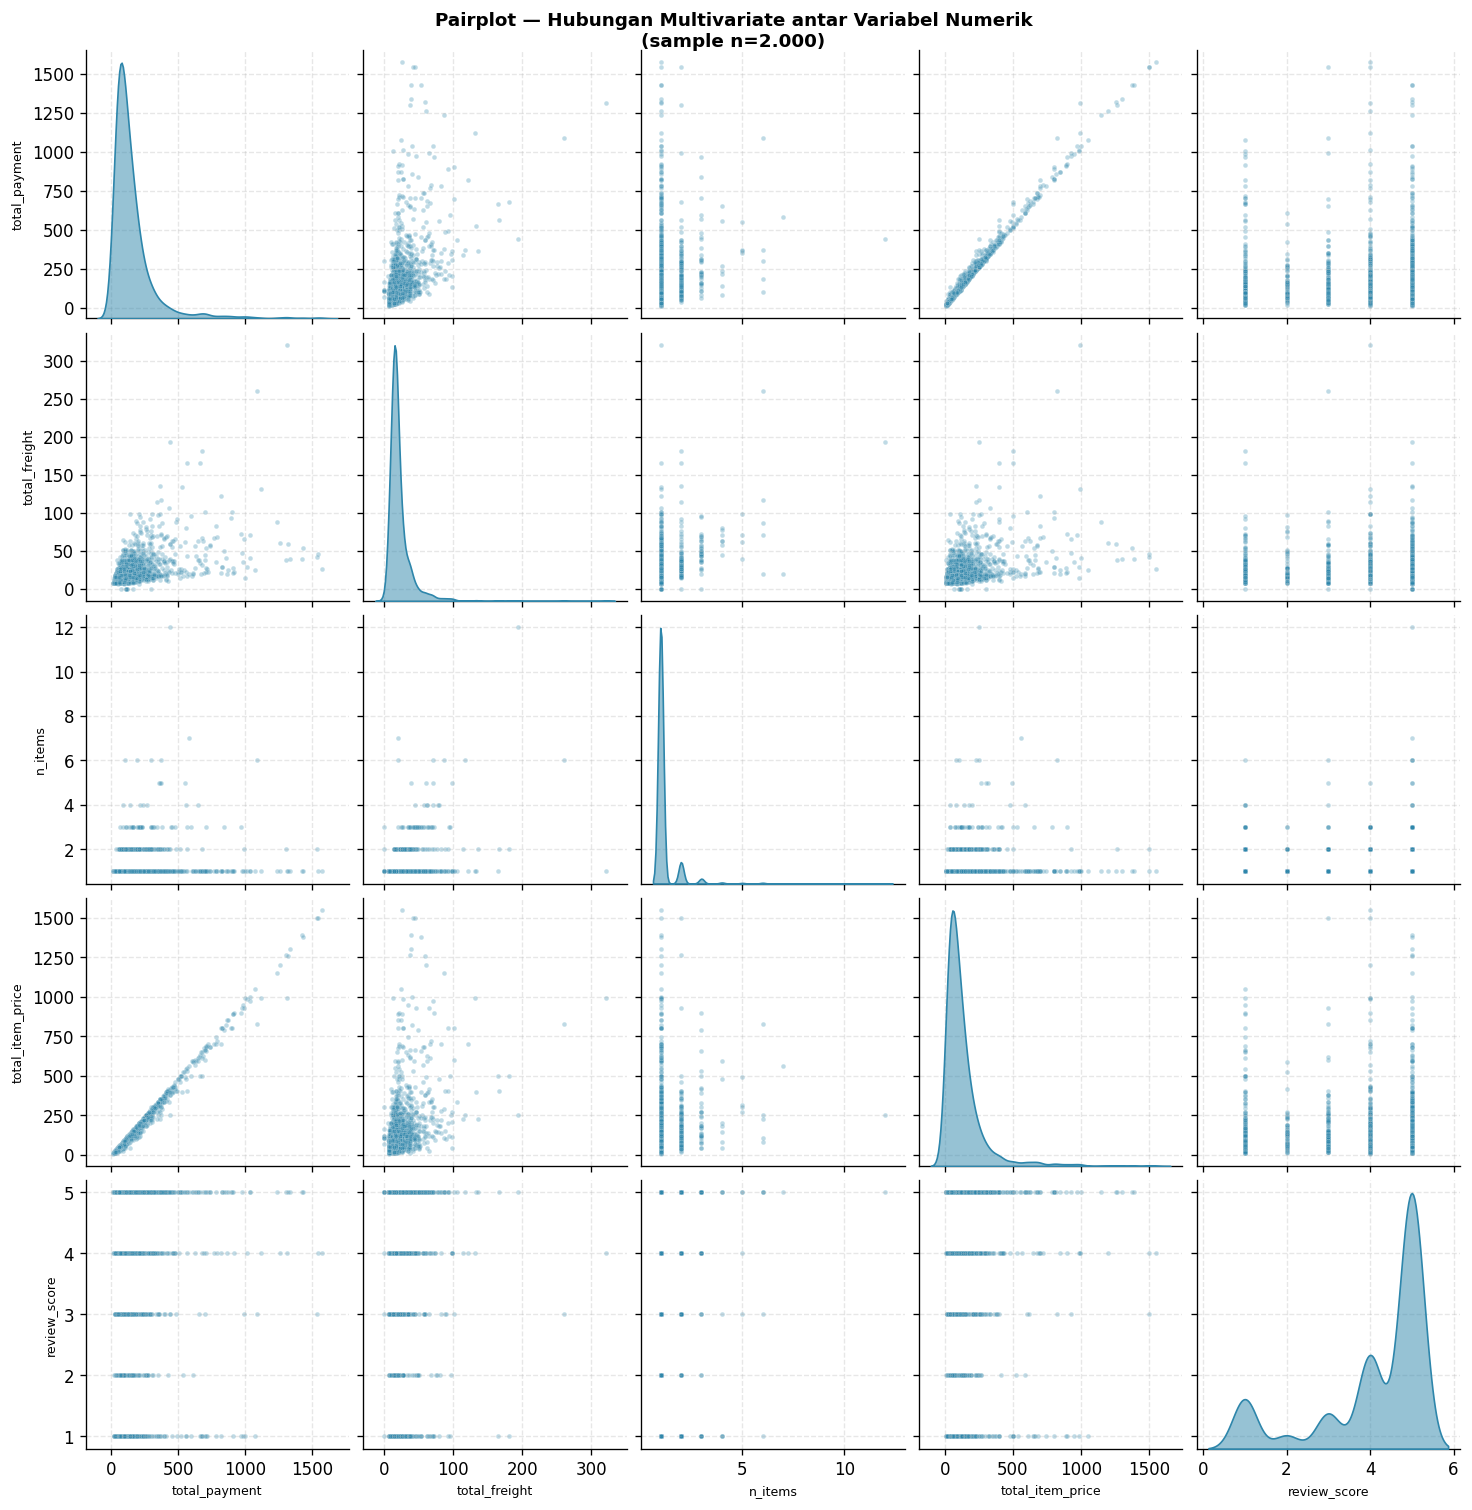

Insight pairplot:
  - Korelasi tertinggi: total_payment vs total_item_price (r=0.990) — hampir linear
  - Korelasi terkuat terhadap review_score: total_freight (r=-0.078)
  - Tidak ada pola linear kuat antara variabel transaksi dengan review_score
    → mengkonfirmasi penggunaan Spearman lebih tepat dari Pearson


In [29]:
# [CODE CELL 28]
# Pairplot untuk melihat semua kombinasi hubungan bivariate sekaligus
# Diagonal: distribusi univariat (KDE)
# Off-diagonal: scatter plot hubungan antar dua variabel
# Sample 2000 untuk efisiensi komputasi
sample_pp = df_main[num_cols].dropna().sample(2000, random_state=42)

g = sns.pairplot(
    sample_pp,
    diag_kind='kde',
    plot_kws={'alpha': 0.3, 'color': '#2E86AB', 's': 8},
    diag_kws={'color': '#2E86AB', 'fill': True, 'alpha': 0.5}
)
g.figure.suptitle('Pairplot — Hubungan Multivariate antar Variabel Numerik\n(sample n=2.000)',
                   y=1.01, fontsize=11, fontweight='bold')

# Highlight kolom review_score
for ax in g.axes[-1, :]:
    ax.set_xlabel(ax.get_xlabel(), fontsize=7.5)
for ax in g.axes[:, 0]:
    ax.set_ylabel(ax.get_ylabel(), fontsize=7.5)

plt.savefig('viz_pairplot.png', dpi=120, bbox_inches='tight')
plt.show()

# Insight dinamis berdasarkan korelasi aktual dari sample_pp
corr_pp = sample_pp.corr(method='spearman')

pairs = corr_pp.unstack().reset_index()
pairs.columns = ['var1', 'var2', 'corr']
pairs = pairs[pairs['var1'] != pairs['var2']].sort_values('corr', ascending=False)
top_var1 = pairs.iloc[0]['var1']
top_var2 = pairs.iloc[0]['var2']
top_val  = pairs.iloc[0]['corr']

review_corrs = corr_pp['review_score'].drop('review_score').sort_values()
neg_var = review_corrs.index[0]
neg_val = review_corrs.iloc[0]

print('Insight pairplot:')
print(f'  - Korelasi tertinggi: {top_var1} vs {top_var2} (r={top_val:.3f}) — hampir linear')
print(f'  - Korelasi terkuat terhadap review_score: {neg_var} (r={neg_val:.3f})')
print(f'  - Tidak ada pola linear kuat antara variabel transaksi dengan review_score')
print(f'    → mengkonfirmasi penggunaan Spearman lebih tepat dari Pearson')

#### EDA Lanjutan 5: Violin Plot — Distribusi Review Score per Segmen

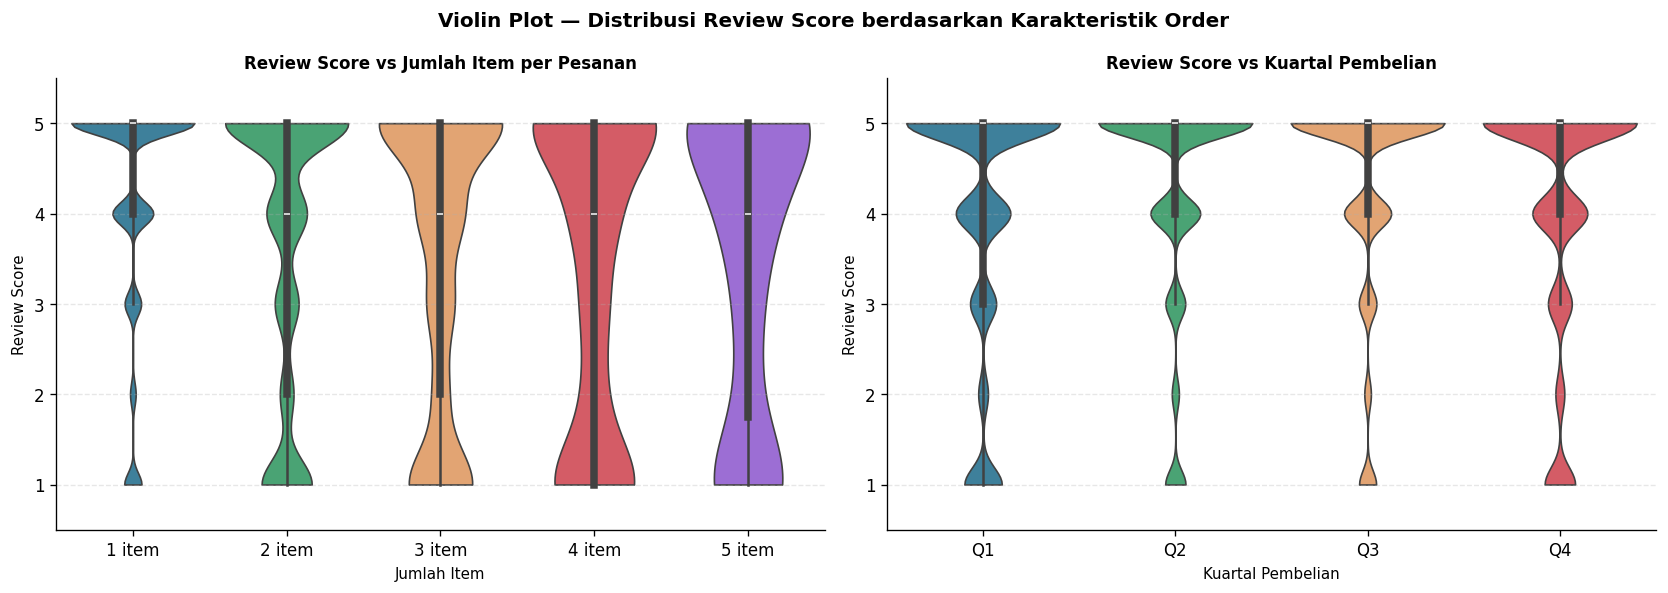

=== Rata-rata Review Score per Jumlah Item ===
          mean    std  count
n_items                     
1        4.214  1.231  86069
2        3.688  1.582   7300
3        3.539  1.629   1281
4        3.369  1.695    485
5        3.474  1.659    192
6        3.380  1.701    184


In [30]:
# [CODE CELL 29]
# Violin Plot: menggabungkan boxplot dan KDE
# Menampilkan distribusi review score berdasarkan jumlah item dalam pesanan
df_violin = df_main[df_main['n_items'] <= 5].copy()
df_violin['n_items_label'] = df_violin['n_items'].apply(lambda x: f'{int(x)} item')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Violin Plot — Distribusi Review Score berdasarkan Karakteristik Order',
             fontsize=12, fontweight='bold')

# Plot 1: Review score vs jumlah item
order_items = [f'{i} item' for i in range(1, 6)]
sns.violinplot(data=df_violin, x='n_items_label', y='review_score',
               order=order_items, ax=axes[0],
               palette=['#2E86AB', '#3BB273', '#F4A261', '#E84855', '#9B5DE5'],
               inner='box', cut=0, linewidth=1)
axes[0].set_title('Review Score vs Jumlah Item per Pesanan', fontsize=10, fontweight='bold')
axes[0].set_xlabel('Jumlah Item', fontsize=9)
axes[0].set_ylabel('Review Score', fontsize=9)
axes[0].set_ylim(0.5, 5.5)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# Plot 2: Review score per bulan pembelian (grouped)
# Kelompokkan bulan menjadi kuartal
df_main_tmp = df_main.copy()
df_main_tmp['kuartal'] = df_main_tmp['purchase_month'].apply(
    lambda x: f'Q{(int(x)-1)//3+1}')
df_pay = df_main_tmp.copy()
sns.violinplot(data=df_pay, x='kuartal', y='review_score',
               order=['Q1','Q2','Q3','Q4'],
               ax=axes[1],
               palette=['#2E86AB', '#3BB273', '#F4A261', '#E84855'],
               inner='box', cut=0, linewidth=1)
axes[1].set_title('Review Score vs Kuartal Pembelian', fontsize=10, fontweight='bold')
axes[1].set_xlabel('Kuartal Pembelian', fontsize=9)
axes[1].set_ylabel('Review Score', fontsize=9)
axes[1].set_ylim(0.5, 5.5)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('viz_violinplot.png', dpi=150, bbox_inches='tight')
plt.show()

# Statistik ringkasan per grup n_items
print('=== Rata-rata Review Score per Jumlah Item ===')
print(df_main.groupby('n_items')['review_score'].agg(['mean','std','count'])
      .query('count >= 50').round(3).head(10).to_string())


#### EDA Lanjutan 6: Chi-Square Test — Uji Hubungan Variabel Kategorikal

Chi-Square test digunakan untuk menguji apakah dua variabel kategorikal **secara statistik
berhubungan** atau bersifat independen (tidak ada hubungan).
- H₀: Kedua variabel independen (tidak ada hubungan)
- H₁: Kedua variabel memiliki hubungan yang signifikan
- Tolak H₀ jika **p-value < 0.05**

In [31]:
# [CODE CELL 30]
from scipy.stats import chi2_contingency, kruskal

# Chi-Square Test 1: Hubungan negara bagian dengan sentimen ulasan
df_chi = df_main.copy()
df_chi['sentiment'] = df_chi['review_score'].apply(
    lambda x: 'Positif' if x >= 4 else 'Negatif' if pd.notna(x) else np.nan
)
df_chi = df_chi.dropna(subset=['sentiment'])

# Top 10 negara bagian
top10_states = df_chi['customer_state'].value_counts().nlargest(10).index
df_chi_state = df_chi[df_chi['customer_state'].isin(top10_states)]

ct1 = pd.crosstab(df_chi_state['customer_state'], df_chi_state['sentiment'])
chi2_1, p1, dof1, _ = chi2_contingency(ct1)

# Chi-Square Test 2: Hubungan jumlah item dengan sentimen ulasan
df_chi['n_items_group'] = df_chi['n_items'].apply(
    lambda x: '1 item' if x == 1 else '2-3 item' if x <= 3 else '4+ item'
)
ct2 = pd.crosstab(df_chi['n_items_group'], df_chi['sentiment'])
chi2_2, p2, dof2, _ = chi2_contingency(ct2)

# Kruskal-Wallis Test: Review score berbeda signifikan antar negara bagian?
groups = [group['review_score'].dropna().values
          for _, group in df_chi_state.groupby('customer_state')]
h_stat, p_kruskal = kruskal(*groups)

print('=== Chi-Square Test ===')
print(f'\n1. Negara Bagian vs Sentimen Ulasan:')
print(f'   Chi2 = {chi2_1:.2f}, df = {dof1}, p-value = {p1:.6f}')
print(f'   Kesimpulan: {"Signifikan — ada hubungan" if p1 < 0.05 else "Tidak signifikan"} (p < 0.05)')
print(f'\n2. Jumlah Item vs Sentimen Ulasan:')
print(f'   Chi2 = {chi2_2:.2f}, df = {dof2}, p-value = {p2:.6f}')
print(f'   Kesimpulan: {"Signifikan — ada hubungan" if p2 < 0.05 else "Tidak signifikan"} (p < 0.05)')
print(f'\n3. Kruskal-Wallis Test (Review Score antar Negara Bagian):')
print(f'   H-statistic = {h_stat:.2f}, p-value = {p_kruskal:.6f}')
print(f'   Kesimpulan: {"Signifikan — review score berbeda antar negara bagian" if p_kruskal < 0.05 else "Tidak signifikan"}')

# Tampilkan crosstab
print('\n=== Crosstab: Jumlah Item vs Sentimen ===')
ct2_pct = ct2.div(ct2.sum(axis=1), axis=0).round(3) * 100
print(ct2_pct.to_string())


=== Chi-Square Test ===

1. Negara Bagian vs Sentimen Ulasan:
   Chi2 = 479.70, df = 9, p-value = 0.000000
   Kesimpulan: Signifikan — ada hubungan (p < 0.05)

2. Jumlah Item vs Sentimen Ulasan:
   Chi2 = 1476.78, df = 2, p-value = 0.000000
   Kesimpulan: Signifikan — ada hubungan (p < 0.05)

3. Kruskal-Wallis Test (Review Score antar Negara Bagian):
   H-statistic = 434.18, p-value = 0.000000
   Kesimpulan: Signifikan — review score berbeda antar negara bagian

=== Crosstab: Jumlah Item vs Sentimen ===
sentiment      Negatif  Positif
n_items_group                  
1 item            19.4     80.6
2-3 item          35.5     64.5
4+ item           42.8     57.2


**Insight - EDA Lanjutan:**

**Distribusi & Outlier:**
- Variabel transaksi (`total_payment`, `total_freight`, `n_items`, `total_item_price`) menunjukkan **distribusi positively skewed** (skewness 7.6–12.3) dengan outlier ekstrem yang signifikan — wajar untuk data transaksi e-commerce.
- **Exception penting**: `review_score` bersifat **negatively skewed** (skewness -1.484) karena mayoritas pelanggan memberikan skor tinggi (59,2% skor 5), sehingga ekor distribusi berada di sisi kiri.
- `total_payment` dan `total_item_price` memiliki skewness tertinggi (9.4 dan 9.9) karena ada produk berharga sangat tinggi.

**Normalitas:**
- Shapiro-Wilk test mengkonfirmasi bahwa **semua variabel tidak berdistribusi normal** (p < 0.05).
- Q-Q Plot menunjukkan deviasi besar dari garis normal terutama di ekor distribusi.
- **Implikasi metodologis**: Korelasi Spearman digunakan (bukan Pearson),
dan Random Forest dipilih karena tidak memerlukan asumsi normalitas.

**Hubungan Antar Variabel:**
- Pairplot mengkonfirmasi korelasi sangat tinggi antara `total_payment` dan `total_item_price`
(hampir linear) — keduanya mewakili informasi yang serupa.
- Tidak ada pola linear yang jelas antara variabel transaksi dengan `review_score`
— mengkonfirmasi hubungan bersifat non-linear.

**Uji Statistik Kategorikal:**
- Chi-Square test mengkonfirmasi hubungan signifikan: **negara bagian** vs sentimen (Chi²=479.70, p<0.05) dan **jumlah item** vs sentimen (Chi²=1476.78, p<0.05).
- Kruskal-Wallis (H=434.18, p<0.05) mengkonfirmasi review score berbeda signifikan antar negara bagian — mendukung relevansi analisis geospatial.
- Violin plot mengkonfirmasi penurunan kepuasan seiring bertambahnya item: 1 item (4.214) → 2 item (3.688) → 3 item (3.539) → 4 item (3.369).

## Visualization & Explanatory Analysis

Tahap ini menyajikan visualisasi data yang dirancang berdasarkan prinsip desain (Data Ink Ratio tinggi, tidak ada chartjunk) dan prinsip integritas (sumbu dimulai dari nol, label jelas, tidak menyembunyikan informasi).

### Pertanyaan 1: Tren Revenue Bulanan dan Kategori Produk Teratas

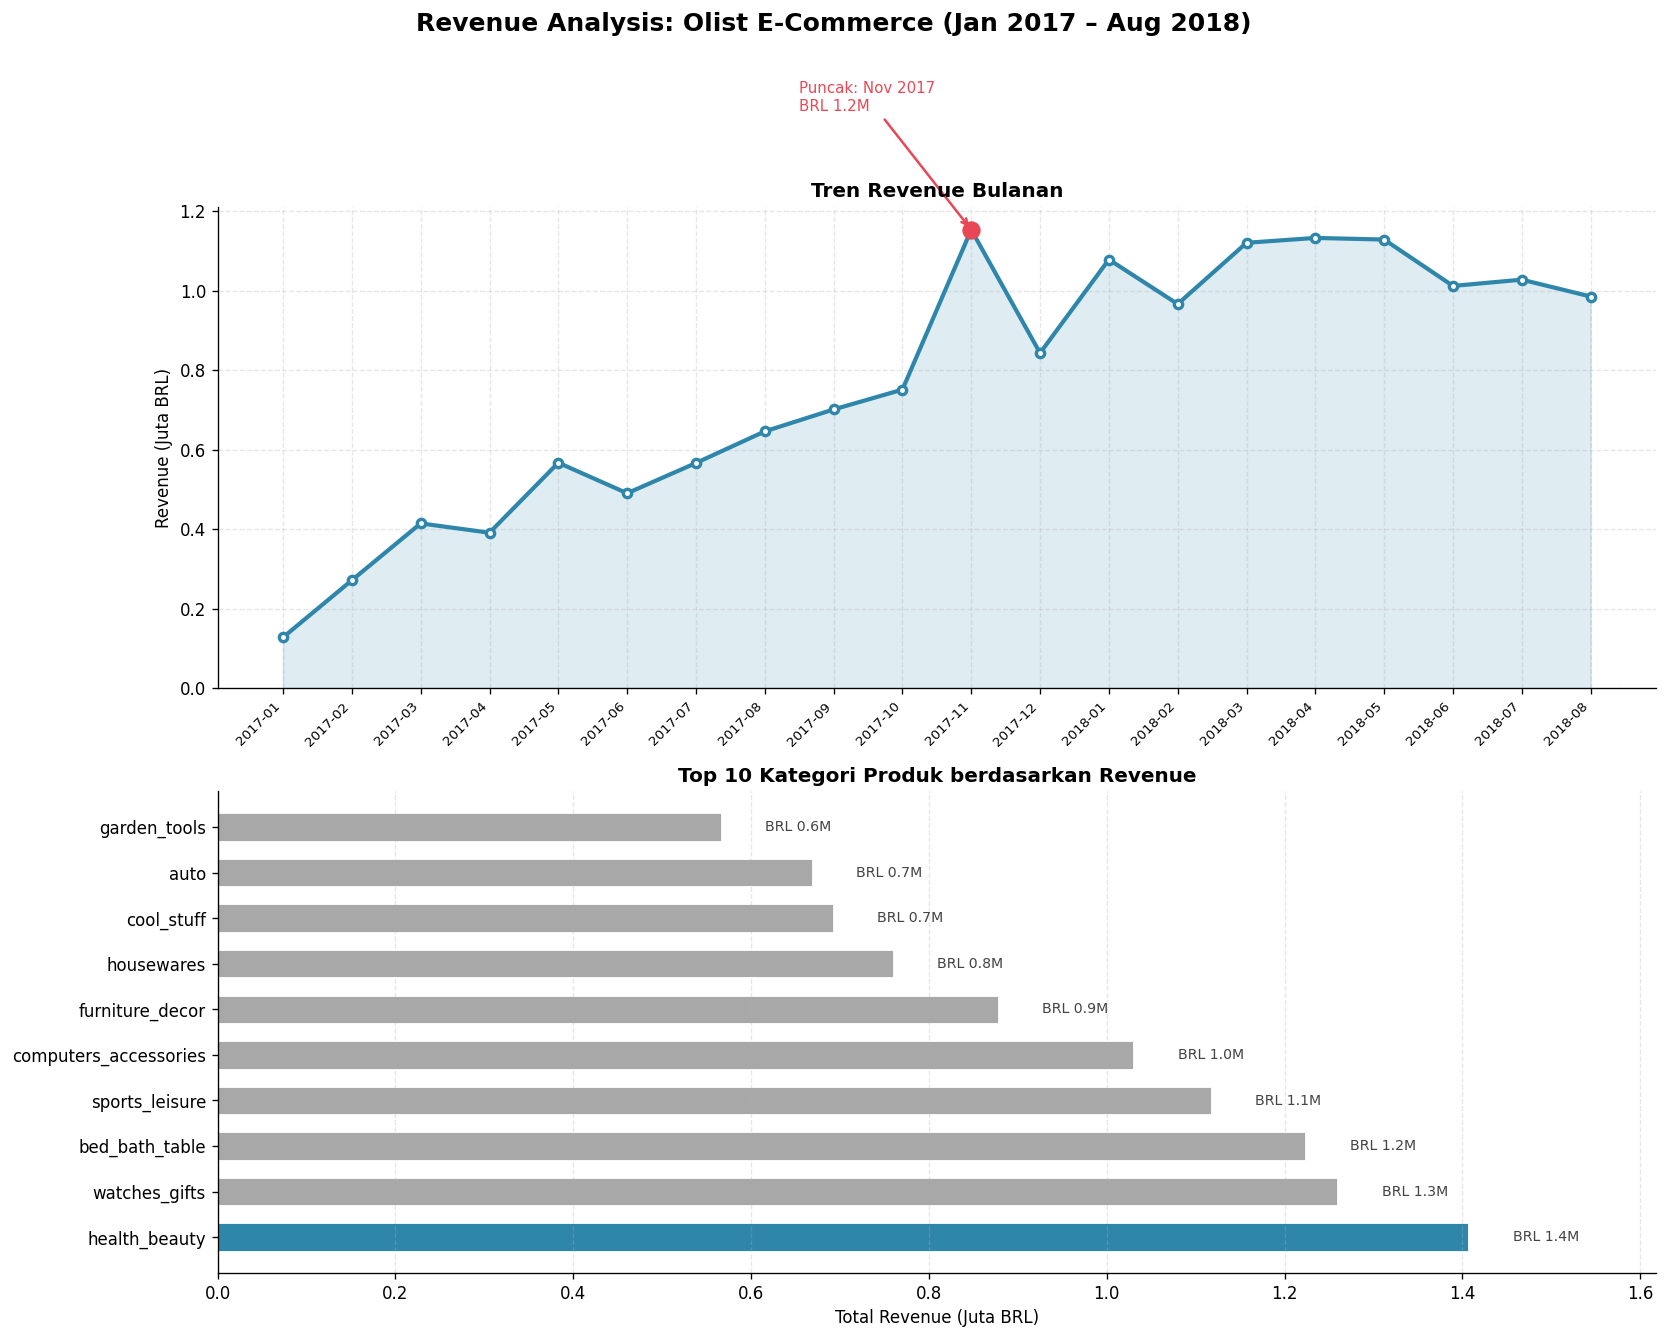

Visualisasi pertanyaan 1 disimpan sebagai viz_question1_revenue.png


In [32]:
# [CODE CELL 31]
# Persiapan data
top10_rev_cats = category_revenue.head(10).copy()

# Palette warna: bar pertama diberi warna aksen, sisanya warna netral
bar_colors = [COLOR_PRIMARY] + [COLOR_NEUTRAL] * 9

# Membuat figure dengan 2 subplot
fig, axes = plt.subplots(2, 1, figsize=(14, 11))
fig.suptitle('Revenue Analysis: Olist E-Commerce (Jan 2017 – Aug 2018)',
             fontsize=15, fontweight='bold', y=1.01)

# --- Plot 1: Tren Revenue Bulanan ---
ax1 = axes[0]

x_vals = range(len(monthly_revenue))

# Area chart untuk konteks visual
ax1.fill_between(x_vals, monthly_revenue['revenue'] / 1e6,
                 alpha=0.15, color=COLOR_PRIMARY)

# Line chart utama
ax1.plot(x_vals, monthly_revenue['revenue'] / 1e6,
         color=COLOR_PRIMARY, linewidth=2.5, marker='o',
         markersize=5, markerfacecolor='white', markeredgewidth=2)

# Menandai titik puncak (Black Friday Nov 2017)
peak_idx = monthly_revenue['revenue'].idxmax()
ax1.plot(peak_idx, monthly_revenue.loc[peak_idx, 'revenue'] / 1e6,
         'o', color=COLOR_ACCENT, markersize=10, zorder=5)
ax1.annotate(
    f"Puncak: Nov 2017\nBRL {monthly_revenue.loc[peak_idx, 'revenue']/1e6:.1f}M",
    xy=(peak_idx, monthly_revenue.loc[peak_idx, 'revenue'] / 1e6),
    xytext=(peak_idx - 2.5, monthly_revenue.loc[peak_idx, 'revenue'] / 1e6 + 0.3),
    fontsize=9, color=COLOR_ACCENT,
    arrowprops=dict(arrowstyle='->', color=COLOR_ACCENT, lw=1.5)
)

# Konfigurasi sumbu
ax1.set_xticks(x_vals)
ax1.set_xticklabels(monthly_revenue['yearmonth_str'], rotation=45, ha='right', fontsize=8)
ax1.set_ylabel('Revenue (Juta BRL)', fontsize=10)
ax1.set_title('Tren Revenue Bulanan', fontsize=12, fontweight='bold')
ax1.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f'))

# Sumbu Y dimulai dari 0 sesuai prinsip integritas visualisasi
ax1.set_ylim(bottom=0)

# --- Plot 2: Top 10 Kategori Berdasarkan Revenue ---
ax2 = axes[1]

# Horizontal bar chart lebih mudah dibaca untuk label panjang
bars = ax2.barh(
    top10_rev_cats['product_category'],
    top10_rev_cats['total_revenue'] / 1e6,
    color=[COLOR_PRIMARY] + [COLOR_NEUTRAL] * 9,
    edgecolor='white', linewidth=0.5, height=0.6
)

# Menambahkan label nilai di ujung setiap bar (prinsip: label jelas)
for bar, val in zip(bars, top10_rev_cats['total_revenue'] / 1e6):
    ax2.text(val + 0.05, bar.get_y() + bar.get_height() / 2,
             f'BRL {val:.1f}M', va='center', fontsize=8.5, color='#444')

ax2.set_xlabel('Total Revenue (Juta BRL)', fontsize=10)
ax2.set_title('Top 10 Kategori Produk berdasarkan Revenue', fontsize=12, fontweight='bold')
ax2.set_xlim(right=top10_rev_cats['total_revenue'].max() / 1e6 * 1.15)

# Sumbu X dimulai dari 0 sesuai prinsip integritas visualisasi
ax2.set_xlim(left=0)

# Hapus grid pada sumbu Y karena tidak relevan untuk horizontal bar
ax2.yaxis.grid(False)
ax2.xaxis.grid(True, alpha=0.3, linestyle='--')

plt.tight_layout()
plt.savefig('viz_question1_revenue.png', dpi=150, bbox_inches='tight')
plt.show()
print('Visualisasi pertanyaan 1 disimpan sebagai viz_question1_revenue.png')

### Pertanyaan 2: Distribusi Kepuasan Pelanggan per Kategori Produk

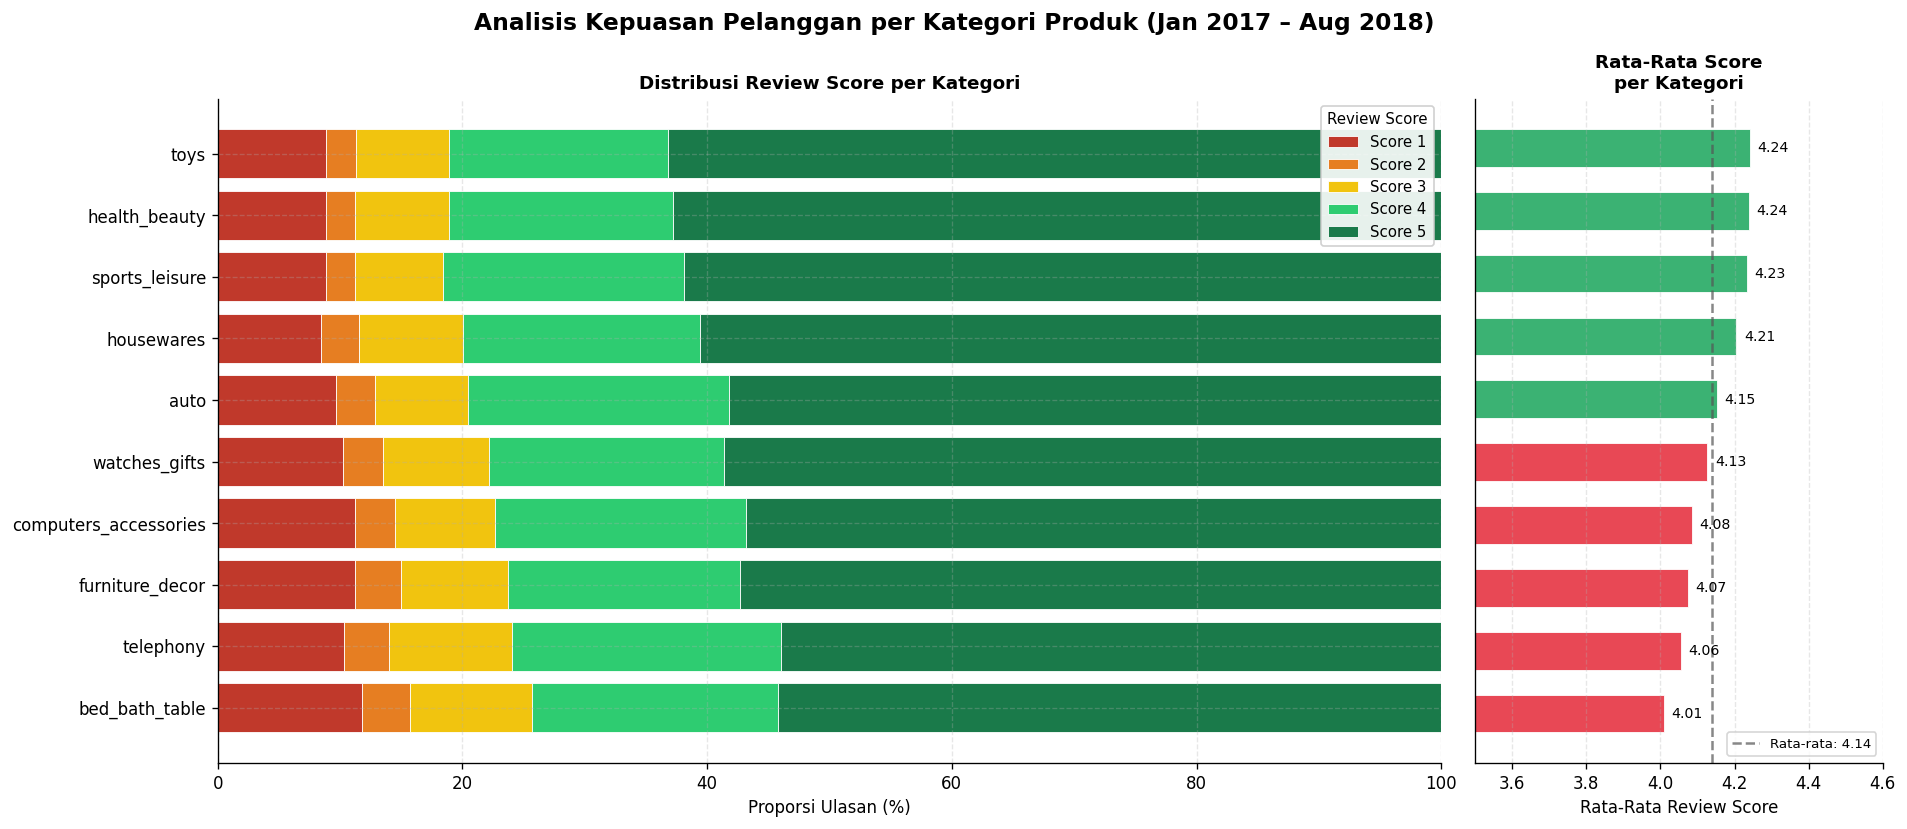

Visualisasi pertanyaan 2 disimpan sebagai viz_question2_review.png


In [33]:
# [CODE CELL 32]
# Persiapan data: hitung proporsi setiap skor (1-5) per kategori
score_by_cat = (
    df_top10
    .groupby(['product_category', 'review_score'])
    .size()
    .unstack(fill_value=0)
    .apply(lambda x: x / x.sum() * 100, axis=1)  # Konversi ke persentase
)

# Urutkan berdasarkan rata-rata skor (terendah di atas agar mudah dibaca)
sorted_cats = category_score['product_category'].tolist()
score_by_cat = score_by_cat.reindex(sorted_cats)

# Palet warna diverging: merah untuk skor rendah, hijau untuk skor tinggi
score_colors = {
    1: '#C0392B',  # Merah tua - sangat tidak puas
    2: '#E67E22',  # Oranye - tidak puas
    3: '#F1C40F',  # Kuning - netral
    4: '#2ECC71',  # Hijau muda - puas
    5: '#1A7A4A'   # Hijau tua - sangat puas
}

# Membuat figure
fig, axes = plt.subplots(1, 2, figsize=(16, 7),
                         gridspec_kw={'width_ratios': [3, 1]})
fig.suptitle('Analisis Kepuasan Pelanggan per Kategori Produk (Jan 2017 – Aug 2018)',
             fontsize=14, fontweight='bold')

# --- Plot 1: Stacked Bar Chart (Distribusi Skor per Kategori) ---
ax1 = axes[0]

bottom = np.zeros(len(score_by_cat))
for score in [1, 2, 3, 4, 5]:
    if score in score_by_cat.columns:
        values = score_by_cat[score].values
        bars = ax1.barh(
            score_by_cat.index,
            values,
            left=bottom,
            color=score_colors[score],
            label=f'Score {score}',
            edgecolor='white', linewidth=0.5
        )
        bottom += values

ax1.set_xlabel('Proporsi Ulasan (%)', fontsize=10)
ax1.set_title('Distribusi Review Score per Kategori', fontsize=11, fontweight='bold')
ax1.set_xlim(0, 100)
ax1.legend(loc='upper right', fontsize=9, title='Review Score',
           title_fontsize=9, framealpha=0.9)

# Menambahkan garis vertikal sebagai referensi kepuasan rata-rata
avg_score5_pct = (df_top10['review_score'] == 5).sum() / len(df_top10) * 100

# --- Plot 2: Rata-Rata Review Score per Kategori ---
ax2 = axes[1]

# Warna bar bergantung pada posisi relatif terhadap rata-rata keseluruhan
overall_avg = df_top10['review_score'].mean()
bar_colors_score = [
    COLOR_ACCENT if v < overall_avg else COLOR_SUCCESS
    for v in category_score['mean']
]

bars2 = ax2.barh(
    category_score['product_category'],
    category_score['mean'],
    color=bar_colors_score,
    edgecolor='white', linewidth=0.5, height=0.6
)

# Garis vertikal rata-rata keseluruhan sebagai referensi
ax2.axvline(x=overall_avg, color='#555', linestyle='--', linewidth=1.5, alpha=0.7,
            label=f'Rata-rata: {overall_avg:.2f}')

# Label nilai pada setiap bar
for bar, val in zip(bars2, category_score['mean']):
    ax2.text(val + 0.02, bar.get_y() + bar.get_height() / 2,
             f'{val:.2f}', va='center', fontsize=8.5)

ax2.set_xlabel('Rata-Rata Review Score', fontsize=10)
ax2.set_title('Rata-Rata Score\nper Kategori', fontsize=11, fontweight='bold')
ax2.set_xlim(3.5, 4.6)
ax2.legend(fontsize=8, loc='lower right')
ax2.set_yticks([])

plt.tight_layout()
plt.savefig('viz_question2_review.png', dpi=150, bbox_inches='tight')
plt.show()
print('Visualisasi pertanyaan 2 disimpan sebagai viz_question2_review.png')

**Insight - Visualization & Explanatory Analysis:**
- **Visualisasi 1 (Revenue)**: Tren line chart mengonfirmasi pertumbuhan yang tidak linear — ada lonjakan tajam menuju November 2017, diikuti penurunan di Desember 2017–Januari 2018, kemudian recovery dan pertumbuhan stabil hingga Agustus 2018. Kategori `health_beauty` (BRL 1,4M) unggul signifikan dari kategori kedua `watches_gifts` (BRL 1,25M).
- **Visualisasi 2 (Kepuasan)**: Stacked bar chart memperlihatkan bahwa hampir semua kategori didominasi warna hijau (skor 4-5), namun `bed_bath_table` dan `telephony` memiliki proporsi warna merah (skor 1-2) yang lebih besar dibanding kategori lain — mengindikasikan ketidakpuasan yang lebih tersebar di kedua kategori ini.
- Penggunaan warna diverging (merah untuk skor rendah, hijau untuk skor tinggi) pada stacked bar chart memudahkan pembaca mengidentifikasi pola kepuasan secara intuitif sesuai prinsip desain visualisasi data.

## Analisis Lanjutan

Bagian ini menerapkan **tujuh teknik analisis lanjutan** yang relevan dengan dataset e-commerce:

**Analisis Berbasis Deskriptif & Segmentasi:**
1. **RFM Analysis** — Segmentasi pelanggan berdasarkan Recency, Frequency, dan Monetary (manual quintile)
2. **Geospatial Analysis** — Distribusi geografis order di seluruh Brazil menggunakan folium
3. **Manual Clustering** — Pengelompokan kategori produk berbasis threshold median (matriks 4 kuadran)

**Analisis Berbasis Machine Learning:**
4. **K-Means Clustering** — Clustering kategori produk dengan algoritma K-Means, evaluasi silhouette score dan elbow method
5. **Random Forest Classification** — Prediksi sentimen ulasan pelanggan (positif/negatif) dengan evaluasi lengkap
6. **Time Series Decomposition** — Dekomposisi tren, musiman, dan residual revenue bulanan
7. **Analisis Korelasi & Feature Importance** — Identifikasi faktor paling berpengaruh terhadap kepuasan pelanggan

### Analisis Lanjutan 1: RFM Analysis (Customer Segmentation)

**Tujuan**: Mengelompokkan pelanggan berdasarkan tiga dimensi perilaku pembelian:
- **Recency (R)**: Seberapa baru pelanggan melakukan transaksi terakhir (dalam hari)
- **Frequency (F)**: Seberapa sering pelanggan melakukan transaksi
- **Monetary (M)**: Berapa total pengeluaran pelanggan

Analisis ini membantu tim marketing memprioritaskan segmen pelanggan yang paling bernilai.

In [34]:
# [CODE CELL 33]
# Menentukan tanggal referensi (1 hari setelah tanggal order terakhir dalam dataset)
reference_date = df_main['order_purchase_timestamp'].max() + pd.Timedelta(days=1)
print(f'Tanggal referensi RFM: {reference_date.date()}')

# Menghitung nilai RFM per pelanggan unik
rfm = (
    df_main
    .groupby('customer_unique_id')
    .agg(
        recency   = ('order_purchase_timestamp', lambda x: (reference_date - x.max()).days),
        frequency = ('order_id', 'count'),
        monetary  = ('total_payment', 'sum')
    )
    .reset_index()
)

print(f'\nJumlah pelanggan unik: {len(rfm):,}')
print('\nStatistik RFM:')
display(rfm[['recency', 'frequency', 'monetary']].describe().round(2))

Tanggal referensi RFM: 2018-08-30

Jumlah pelanggan unik: 93,104

Statistik RFM:


,recency,frequency,monetary
count,93104.00,93104.00,93104.00
mean,236.70,1.03,165.15
std,150.94,0.21,226.38
min,1.00,1.00,9.59
25%,114.00,1.00,63.04
50%,218.00,1.00,107.78
75%,345.00,1.00,182.50
max,602.00,15.00,13664.08


In [35]:
# [CODE CELL 34]
# Membuat skor RFM menggunakan metode quintile (pembagian menjadi 5 kelompok)
# Recency: skor tinggi (5) = baru belanja, skor rendah (1) = lama tidak belanja
# Frequency & Monetary: skor tinggi (5) = nilai tinggi

rfm['R_score'] = pd.qcut(rfm['recency'], q=5, labels=[5, 4, 3, 2, 1])
rfm['F_score'] = pd.qcut(rfm['frequency'].rank(method='first'), q=5, labels=[1, 2, 3, 4, 5])
rfm['M_score'] = pd.qcut(rfm['monetary'], q=5, labels=[1, 2, 3, 4, 5])

# Konversi ke integer dan buat RFM combined score
rfm['R_score'] = rfm['R_score'].astype(int)
rfm['F_score'] = rfm['F_score'].astype(int)
rfm['M_score'] = rfm['M_score'].astype(int)
rfm['RFM_score'] = rfm['R_score'].astype(str) + rfm['F_score'].astype(str) + rfm['M_score'].astype(str)
rfm['RFM_total'] = rfm['R_score'] + rfm['F_score'] + rfm['M_score']

# Segmentasi pelanggan berdasarkan kombinasi skor R dan F
def segment_customer(row):
    r, f = row['R_score'], row['F_score']
    if r >= 4 and f >= 4:
        return 'Champions'
    elif r >= 3 and f >= 3:
        return 'Loyal Customers'
    elif r >= 4 and f <= 2:
        return 'New Customers'
    elif r >= 3 and f <= 2:
        return 'Potential Loyalists'
    elif r <= 2 and f >= 3:
        return 'At Risk'
    elif r <= 2 and f <= 2:
        return 'Lost Customers'
    else:
        return 'Need Attention'

rfm['segment'] = rfm.apply(segment_customer, axis=1)

# Ringkasan per segmen
segment_summary = (
    rfm.groupby('segment')
    .agg(
        n_customers  = ('customer_unique_id', 'count'),
        avg_recency  = ('recency', 'mean'),
        avg_frequency= ('frequency', 'mean'),
        avg_monetary = ('monetary', 'mean'),
        total_revenue= ('monetary', 'sum')
    )
    .round(2)
    .sort_values('total_revenue', ascending=False)
    .reset_index()
)

print('Ringkasan segmen pelanggan RFM:')
display(segment_summary)

Ringkasan segmen pelanggan RFM:


,segment,n_customers,avg_recency,avg_frequency,avg_monetary,total_revenue
0,At Risk,22079,392.65,1.05,166.98,3686761.05
1,Loyal Customers,18823,168.82,1.03,161.31,3036390.59
2,Champions,14960,90.22,1.09,176.92,2646760.88
3,New Customers,14985,90.88,1.00,163.42,2448921.30
4,Lost Customers,14883,393.43,1.00,162.68,2421165.78
5,Potential Loyalists,7374,220.24,1.00,154.04,1135875.84


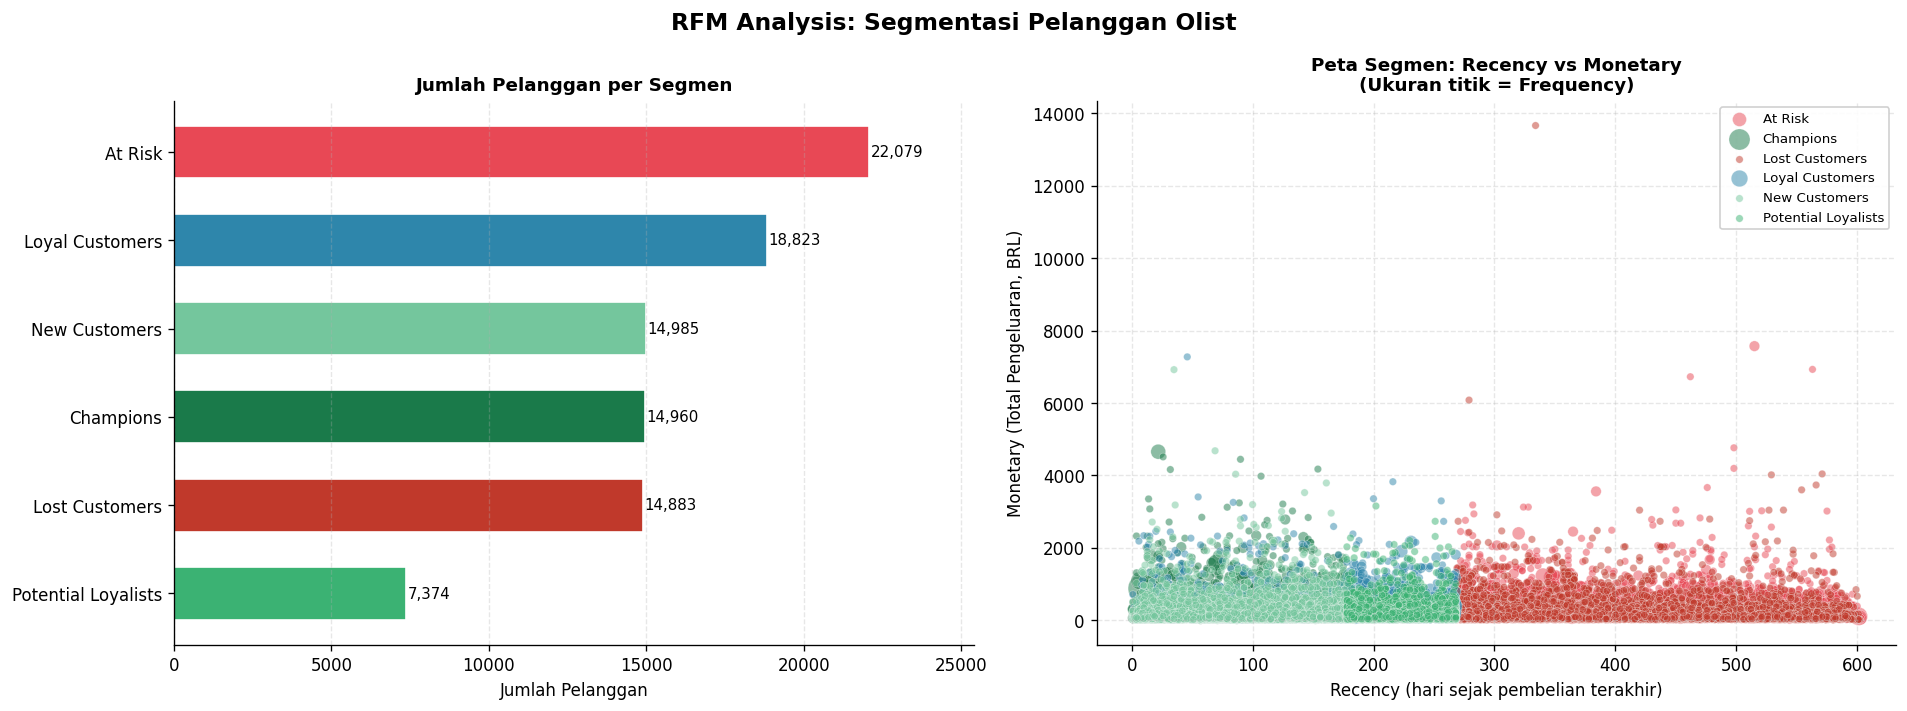

Visualisasi RFM disimpan sebagai viz_rfm_analysis.png


In [36]:
# [CODE CELL 35]
# Visualisasi RFM: Treemap-style bar chart dan scatter plot
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('RFM Analysis: Segmentasi Pelanggan Olist', fontsize=14, fontweight='bold')

# Palet warna per segmen
segment_colors = {
    'Champions'          : '#1A7A4A',
    'Loyal Customers'    : '#2E86AB',
    'Potential Loyalists': '#3BB273',
    'New Customers'      : '#74C69D',
    'Need Attention'     : '#F4A261',
    'At Risk'            : '#E84855',
    'Lost Customers'     : '#C0392B'
}

# --- Plot 1: Jumlah Pelanggan per Segmen ---
ax1 = axes[0]
sorted_seg = segment_summary.sort_values('n_customers', ascending=True)
colors_seg = [segment_colors.get(s, COLOR_NEUTRAL) for s in sorted_seg['segment']]

bars = ax1.barh(sorted_seg['segment'], sorted_seg['n_customers'],
                color=colors_seg, edgecolor='white', height=0.6)

for bar, val in zip(bars, sorted_seg['n_customers']):
    ax1.text(val + 50, bar.get_y() + bar.get_height() / 2,
             f'{val:,}', va='center', fontsize=9)

ax1.set_xlabel('Jumlah Pelanggan', fontsize=10)
ax1.set_title('Jumlah Pelanggan per Segmen', fontsize=11, fontweight='bold')
ax1.set_xlim(left=0, right=sorted_seg['n_customers'].max() * 1.15)
ax1.yaxis.grid(False)

# --- Plot 2: Scatter Plot Recency vs Monetary (ukuran titik = frequency) ---
ax2 = axes[1]

for segment, group in rfm.groupby('segment'):
    ax2.scatter(
        group['recency'],
        group['monetary'],
        c=segment_colors.get(segment, COLOR_NEUTRAL),
        s=group['frequency'] * 20,
        alpha=0.5, label=segment, edgecolors='white', linewidths=0.3
    )

ax2.set_xlabel('Recency (hari sejak pembelian terakhir)', fontsize=10)
ax2.set_ylabel('Monetary (Total Pengeluaran, BRL)', fontsize=10)
ax2.set_title('Peta Segmen: Recency vs Monetary\n(Ukuran titik = Frequency)', fontsize=11, fontweight='bold')
ax2.legend(fontsize=8, loc='upper right', framealpha=0.9)

plt.tight_layout()
plt.savefig('viz_rfm_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Visualisasi RFM disimpan sebagai viz_rfm_analysis.png')

### Analisis Lanjutan 2: Geospatial Analysis

**Tujuan**: Menganalisis distribusi geografis order di seluruh negara bagian Brazil untuk mengidentifikasi konsentrasi pasar dan peluang ekspansi.

Analisis ini menggunakan library `folium` untuk membuat peta interaktif dan `seaborn` untuk visualisasi statis distribusi per negara bagian.

In [37]:
# [CODE CELL 36]
# Menghitung jumlah order dan total revenue per negara bagian pelanggan
state_stats = (
    df_main
    .groupby('customer_state')
    .agg(
        n_orders     = ('order_id', 'count'),
        total_revenue= ('total_payment', 'sum'),
        avg_score    = ('review_score', 'mean')
    )
    .reset_index()
    .sort_values('n_orders', ascending=False)
)

print('Top 10 negara bagian berdasarkan jumlah order:')
display(state_stats.head(10))

Top 10 negara bagian berdasarkan jumlah order:


,customer_state,n_orders,total_revenue,avg_score
25,SP,40406,5756706.26,4.246727
18,RJ,12310,2046698.14,3.965577
10,MG,11319,1814317.79,4.193227
22,RS,5328,858904.29,4.185311
17,PR,4903,779319.58,4.240984
23,SC,3537,592707.68,4.134188
4,BA,3253,590949.59,3.929324
6,DF,2074,344946.06,4.135659
7,ES,1992,316690.84,4.078840
8,GO,1950,333238.10,4.101599


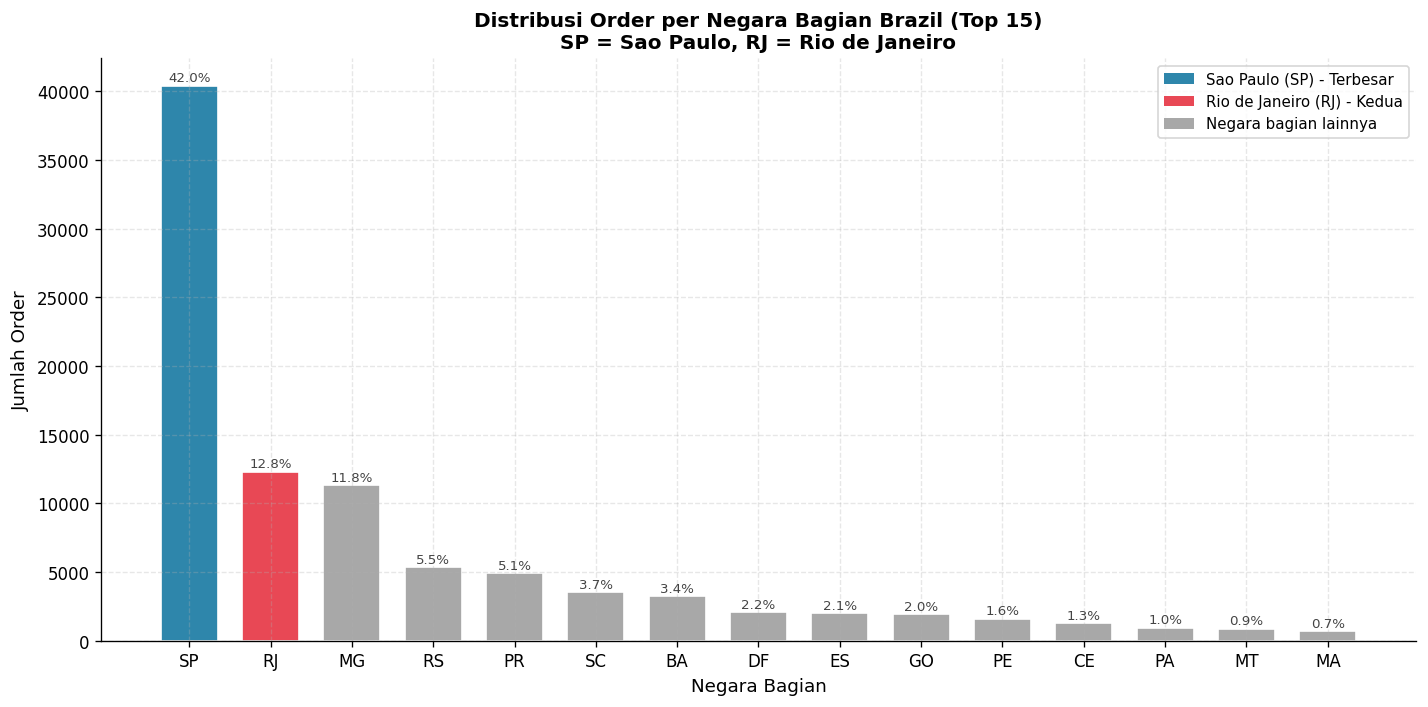

In [38]:
# [CODE CELL 37]
# Visualisasi bar chart distribusi order per negara bagian (top 15)
top15_states = state_stats.head(15)

fig, ax = plt.subplots(figsize=(12, 6))

bar_colors_state = [COLOR_PRIMARY if s == 'SP' else
                    COLOR_ACCENT  if s == 'RJ' else
                    COLOR_NEUTRAL for s in top15_states['customer_state']]

bars = ax.bar(top15_states['customer_state'], top15_states['n_orders'],
              color=bar_colors_state, edgecolor='white', width=0.7)

# Menambahkan label persentase di atas setiap bar
total_orders = state_stats['n_orders'].sum()
for bar, n in zip(bars, top15_states['n_orders']):
    pct = n / total_orders * 100
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 100,
            f'{pct:.1f}%', ha='center', va='bottom', fontsize=8, color='#444')

ax.set_xlabel('Negara Bagian', fontsize=11)
ax.set_ylabel('Jumlah Order', fontsize=11)
ax.set_title('Distribusi Order per Negara Bagian Brazil (Top 15)\nSP = Sao Paulo, RJ = Rio de Janeiro',
             fontsize=12, fontweight='bold')
ax.set_ylim(bottom=0)

# Legend manual untuk highlight
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=COLOR_PRIMARY, label='Sao Paulo (SP) - Terbesar'),
    Patch(facecolor=COLOR_ACCENT,  label='Rio de Janeiro (RJ) - Kedua'),
    Patch(facecolor=COLOR_NEUTRAL, label='Negara bagian lainnya')
]
ax.legend(handles=legend_elements, fontsize=9, loc='upper right')

plt.tight_layout()
plt.savefig('viz_geospatial_bar.png', dpi=150, bbox_inches='tight')
plt.show()

In [39]:
# [CODE CELL 38]
# Membuat peta interaktif heatmap menggunakan folium
# Menggabungkan koordinat pelanggan melalui kode pos
customer_geo = (
    df_customers[['customer_unique_id', 'customer_zip_code_prefix']]
    .merge(df_geo_unique.rename(columns={'geolocation_zip_code_prefix': 'customer_zip_code_prefix'}),
           on='customer_zip_code_prefix', how='left')
    .dropna(subset=['geolocation_lat', 'geolocation_lng'])
)

# Gabungkan dengan data order untuk mendapatkan pelanggan aktif saja
active_customer_ids = df_main['customer_unique_id'].unique()
customer_geo_active = customer_geo[
    customer_geo['customer_unique_id'].isin(active_customer_ids)
]

# Batasi jumlah titik untuk performa (ambil sampel acak 10.000 titik)
sample_geo = customer_geo_active.sample(
    n=min(10000, len(customer_geo_active)),
    random_state=42
)

# Membuat peta folium dengan pusat di Brazil
m = folium.Map(
    location=[-14.0, -51.0],  # Koordinat pusat Brazil
    zoom_start=4,
    tiles='CartoDB positron'   # Tile peta yang bersih
)

# Menambahkan heatmap layer
heat_data = [
    [row['geolocation_lat'], row['geolocation_lng']]
    for _, row in sample_geo.iterrows()
]

HeatMap(
    heat_data,
    radius=8,
    blur=10,
    min_opacity=0.3,
    gradient={0.2: '#3B4CC0', 0.5: '#88BEDC', 0.75: '#F7E589', 1.0: '#B40426'}
).add_to(m)

# Menambahkan judul pada peta
title_html = '''
    <div style="position: fixed; top: 10px; left: 50%; transform: translateX(-50%);
                background: white; padding: 8px 16px; border-radius: 4px;
                border: 1px solid #ccc; font-size: 14px; font-weight: bold;
                z-index: 1000; box-shadow: 2px 2px 6px rgba(0,0,0,0.2);">
        Peta Distribusi Pelanggan Olist di Brazil (Jan 2017 - Aug 2018)
    </div>
'''
m.get_root().html.add_child(folium.Element(title_html))

# Simpan sebagai HTML interaktif
m.save('viz_geospatial_map.html')
print(f'Peta interaktif disimpan sebagai viz_geospatial_map.html')
print(f'Jumlah titik pada peta: {len(sample_geo):,}')

# Tampilkan peta di notebook
display(m)

Peta interaktif disimpan sebagai viz_geospatial_map.html
Jumlah titik pada peta: 10,000


### Analisis Lanjutan 3: Clustering Kategori Produk

**Tujuan**: Mengelompokkan kategori produk ke dalam klaster berdasarkan kombinasi dua dimensi performa bisnis:
- **Revenue** (total pendapatan)
- **Kepuasan pelanggan** (rata-rata review score)

Metode yang digunakan adalah **manual binning** (tanpa machine learning) menggunakan nilai median sebagai threshold pembagian klaster.

In [40]:
# [CODE CELL 39]
# Menyiapkan data kategori untuk clustering
# Ambil semua kategori dengan minimal 50 order untuk representasi yang cukup
category_cluster_data = (
    df_main[df_main['product_category'] != 'unknown']
    .groupby('product_category')
    .agg(
        total_revenue = ('total_payment', 'sum'),
        avg_score     = ('review_score', 'mean'),
        n_orders      = ('order_id', 'count')
    )
    .reset_index()
)

# Filter kategori dengan minimal 50 order
category_cluster_data = category_cluster_data[
    category_cluster_data['n_orders'] >= 50
].copy()

# Menggunakan nilai median sebagai threshold untuk membagi menjadi 4 kuadran
median_revenue = category_cluster_data['total_revenue'].median()
median_score   = category_cluster_data['avg_score'].median()

print(f'Median total revenue: BRL {median_revenue:,.0f}')
print(f'Median rata-rata skor: {median_score:.3f}')

# Membuat label cluster berdasarkan posisi relatif terhadap median
def assign_cluster(row):
    high_rev   = row['total_revenue'] >= median_revenue
    high_score = row['avg_score'] >= median_score
    if high_rev and high_score:
        return 'Stars'           # Revenue tinggi, kepuasan tinggi
    elif high_rev and not high_score:
        return 'Cash Cows'       # Revenue tinggi, kepuasan rendah
    elif not high_rev and high_score:
        return 'Rising Stars'    # Revenue rendah, kepuasan tinggi
    else:
        return 'Underperformers' # Revenue rendah, kepuasan rendah

category_cluster_data['cluster'] = category_cluster_data.apply(assign_cluster, axis=1)

# Ringkasan distribusi per klaster
cluster_summary = (
    category_cluster_data.groupby('cluster')
    .agg(n_categories=('product_category', 'count'))
    .reset_index()
)
print('\nJumlah kategori per cluster:')
display(cluster_summary)

Median total revenue: BRL 85,735
Median rata-rata skor: 4.194

Jumlah kategori per cluster:


,cluster,n_categories
0,Cash Cows,14
1,Rising Stars,14
2,Stars,15
3,Underperformers,14


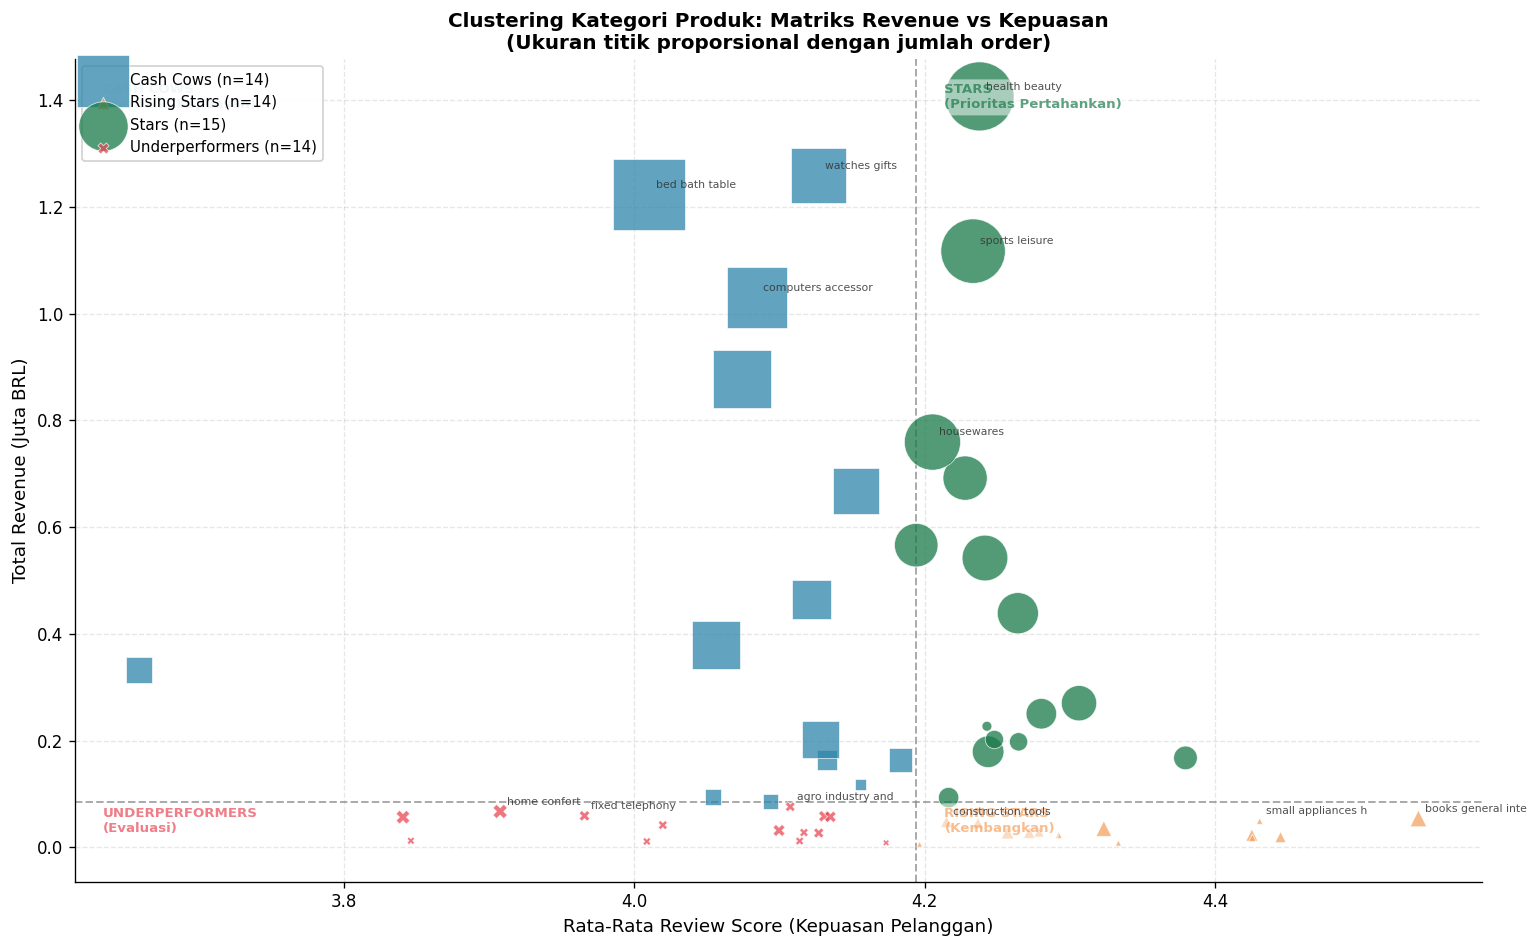

Visualisasi clustering disimpan sebagai viz_clustering.png


In [41]:
# [CODE CELL 40]
# Visualisasi cluster: Scatter plot 4 kuadran
fig, ax = plt.subplots(figsize=(13, 8))

cluster_colors = {
    'Stars'          : '#1A7A4A',
    'Cash Cows'      : '#2E86AB',
    'Rising Stars'   : '#F4A261',
    'Underperformers': '#E84855'
}

cluster_markers = {
    'Stars'          : 'o',
    'Cash Cows'      : 's',
    'Rising Stars'   : '^',
    'Underperformers': 'X'
}

for cluster_name, group in category_cluster_data.groupby('cluster'):
    ax.scatter(
        group['avg_score'],
        group['total_revenue'] / 1e6,
        c=cluster_colors[cluster_name],
        marker=cluster_markers[cluster_name],
        s=group['n_orders'] / 5,  # Ukuran titik proporsional dengan jumlah order
        label=f'{cluster_name} (n={len(group)})',
        alpha=0.75, edgecolors='white', linewidths=0.5, zorder=3
    )

# Garis threshold median sebagai pembatas kuadran
ax.axvline(x=median_score,   color='#888', linestyle='--', linewidth=1.2, alpha=0.7, zorder=2)
ax.axhline(y=median_revenue / 1e6, color='#888', linestyle='--', linewidth=1.2, alpha=0.7, zorder=2)

# Label kuadran di pojok setiap area
ax_xlim  = ax.get_xlim()
ax_ylim  = ax.get_ylim()
text_offset_x = (ax_xlim[1] - ax_xlim[0]) * 0.02
text_offset_y = (ax_ylim[1] - ax_ylim[0]) * 0.03

quadrant_labels = [
    (median_score + text_offset_x, ax_ylim[1] - text_offset_y*2, 'STARS\n(Prioritas Pertahankan)', 'left',  '#1A7A4A'),
    (ax_xlim[0]   + text_offset_x, ax_ylim[1] - text_offset_y*2, 'CASH COWS\n(Perbaiki Kepuasan)',  'left',  '#2E86AB'),
    (median_score + text_offset_x, ax_ylim[0] + text_offset_y*2, 'RISING STARS\n(Kembangkan)',      'left',  '#F4A261'),
    (ax_xlim[0]   + text_offset_x, ax_ylim[0] + text_offset_y*2, 'UNDERPERFORMERS\n(Evaluasi)',     'left',  '#E84855'),
]

for qx, qy, qlabel, qha, qcolor in quadrant_labels:
    ax.text(qx, qy, qlabel, ha=qha, fontsize=8, color=qcolor,
            fontweight='bold', alpha=0.7,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.5, edgecolor='none'))

# Label beberapa kategori penting (top 5 per cluster untuk keterbacaan)
top_to_label = (
    category_cluster_data
    .sort_values('total_revenue', ascending=False)
    .groupby('cluster')
    .head(3)
)

for _, row in top_to_label.iterrows():
    short_name = row['product_category'].replace('_', ' ')[:18]
    ax.annotate(
        short_name,
        xy=(row['avg_score'], row['total_revenue'] / 1e6),
        xytext=(4, 4), textcoords='offset points',
        fontsize=6.5, color='#333', alpha=0.85
    )

ax.set_xlabel('Rata-Rata Review Score (Kepuasan Pelanggan)', fontsize=11)
ax.set_ylabel('Total Revenue (Juta BRL)', fontsize=11)
ax.set_title('Clustering Kategori Produk: Matriks Revenue vs Kepuasan\n(Ukuran titik proporsional dengan jumlah order)',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=9, loc='upper left', framealpha=0.9)

plt.tight_layout()
plt.savefig('viz_clustering.png', dpi=150, bbox_inches='tight')
plt.show()
print('Visualisasi clustering disimpan sebagai viz_clustering.png')

### Analisis Lanjutan 4: K-Means Clustering Kategori Produk

**Tujuan**: Mengelompokkan 71 kategori produk menggunakan algoritma **K-Means** berdasarkan lima dimensi performa bisnis:
- `total_revenue` — total pendapatan kategori
- `n_orders` — jumlah pesanan
- `avg_score` — rata-rata kepuasan pelanggan
- `avg_freight` — rata-rata biaya pengiriman
- `avg_items` — rata-rata jumlah item per pesanan

**Alasan pemilihan K-Means**:
- Cocok untuk data numerik kontinu dengan skala beragam (setelah standarisasi)
- Interpretabel dan efisien untuk jumlah kategori yang tidak terlalu besar (n=71)
- Alternatif yang dipertimbangkan: DBSCAN (kurang cocok karena tidak ada noise yang jelas) dan Hierarchical Clustering (terlalu lambat untuk iterasi)

**Skenario pengujian**:
- K dicari menggunakan Elbow Method (inertia) dan Silhouette Score untuk K = 2 hingga 10
- Standarisasi fitur menggunakan StandardScaler sebelum clustering
- Evaluasi akhir menggunakan Silhouette Score sebagai metrik utama

In [42]:
# [CODE CELL 41]
# Menyiapkan data untuk K-Means clustering
# Ambil semua kategori dengan minimal 50 order untuk representasi yang memadai
cat_km = (
    df_main[df_main['product_category'] != 'unknown']
    .groupby('product_category')
    .agg(
        total_revenue = ('total_payment', 'sum'),
        n_orders      = ('order_id', 'count'),
        avg_score     = ('review_score', 'mean'),
        avg_freight   = ('total_freight', 'mean'),
        avg_items     = ('n_items', 'mean')
    )
    .reset_index()
)
cat_km = cat_km[cat_km['n_orders'] >= 50].copy()
cat_km = cat_km.dropna().reset_index(drop=True)

print(f'Jumlah kategori untuk clustering: {len(cat_km)}')
print('\nStatistik deskriptif fitur clustering:')
display(cat_km[['total_revenue','n_orders','avg_score','avg_freight','avg_items']].describe().round(2))

Jumlah kategori untuk clustering: 57

Statistik deskriptif fitur clustering:


,total_revenue,n_orders,avg_score,avg_freight,avg_items
count,57.00,57.00,57.00,57.00,57.00
mean,265480.19,1657.63,4.18,25.86,1.14
std,363633.18,2351.12,0.16,9.93,0.09
min,5893.27,56.00,3.66,15.85,1.01
25%,28954.34,191.00,4.11,19.52,1.08
50%,85734.66,409.00,4.19,22.40,1.12
75%,332519.50,2506.00,4.26,28.31,1.19
max,1406712.12,9162.00,4.54,54.83,1.43


In [43]:
# [CODE CELL 42]
# Standarisasi fitur agar semua dimensi berada pada skala yang sama
# StandardScaler mengubah setiap fitur menjadi mean=0 dan std=1
features_km = ['total_revenue', 'n_orders', 'avg_score', 'avg_freight', 'avg_items']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(cat_km[features_km])

print('Fitur setelah standarisasi (5 baris pertama):')
print(pd.DataFrame(X_scaled, columns=features_km).head().round(3))

# Menentukan K optimal menggunakan Elbow Method dan Silhouette Score
k_range    = range(2, 11)
inertias   = []
sil_scores = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, km.labels_))

# Tampilkan hasil pencarian K optimal
k_results = pd.DataFrame({
    'K': list(k_range),
    'Inertia': inertias,
    'Silhouette Score': sil_scores
})
print('\nHasil pencarian K optimal:')
display(k_results.round(4))
print(f'\nK terbaik berdasarkan Silhouette Score: K={k_results.loc[k_results["Silhouette Score"].idxmax(), "K"]}')

Fitur setelah standarisasi (5 baris pertama):
   total_revenue  n_orders  avg_score  avg_freight  avg_items
0         -0.525    -0.635     -0.447        0.609      0.234
1         -0.575    -0.608     -0.296        0.065      0.258
2         -0.662    -0.629     -0.321       -0.613     -1.374
3         -0.579    -0.565     -2.163       -0.954     -1.083
4          1.117     0.913     -0.157       -0.207     -0.575

Hasil pencarian K optimal:


,K,Inertia,Silhouette Score
0,2,194.8821,0.3306
1,3,140.3349,0.3025
2,4,114.9278,0.2837
3,5,96.5354,0.2801
4,6,83.0102,0.2721
5,7,68.7461,0.2782
6,8,60.7732,0.2768
7,9,53.2696,0.3015
8,10,45.8383,0.2845



K terbaik berdasarkan Silhouette Score: K=2


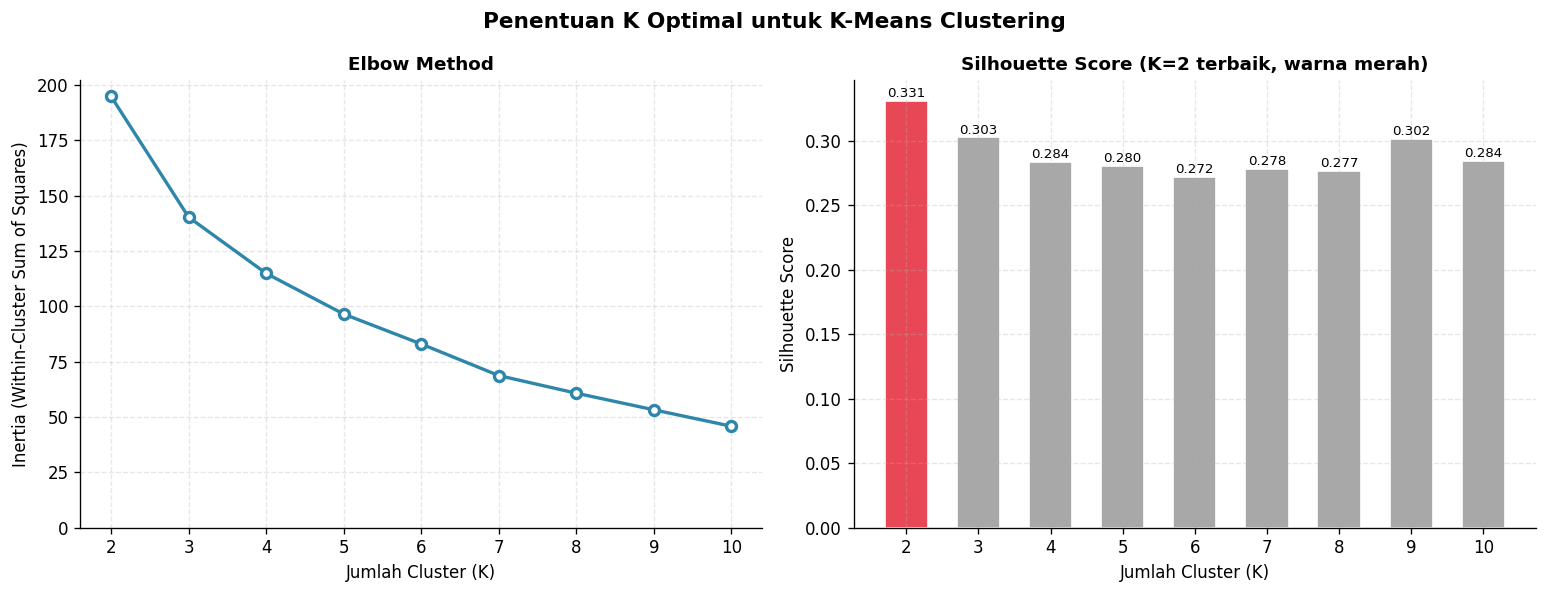

Visualisasi disimpan sebagai viz_kmeans_elbow.png


In [44]:
# [CODE CELL 43]
# Visualisasi Elbow Method dan Silhouette Score untuk pemilihan K
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Penentuan K Optimal untuk K-Means Clustering', fontsize=13, fontweight='bold')

k_list = list(k_range)

# Plot Elbow Method
ax1 = axes[0]
ax1.plot(k_list, inertias, marker='o', color=COLOR_PRIMARY,
         linewidth=2, markersize=6, markerfacecolor='white', markeredgewidth=2)
ax1.set_xlabel('Jumlah Cluster (K)', fontsize=10)
ax1.set_ylabel('Inertia (Within-Cluster Sum of Squares)', fontsize=10)
ax1.set_title('Elbow Method', fontsize=11, fontweight='bold')
ax1.set_xticks(k_list)
ax1.set_ylim(bottom=0)

# Plot Silhouette Score
ax2 = axes[1]
best_k   = k_results.loc[k_results['Silhouette Score'].idxmax(), 'K']
bar_cols = [COLOR_ACCENT if k == best_k else COLOR_NEUTRAL for k in k_list]
bars     = ax2.bar(k_list, sil_scores, color=bar_cols, edgecolor='white', width=0.6)

for bar, score in zip(bars, sil_scores):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
             f'{score:.3f}', ha='center', fontsize=8)

ax2.set_xlabel('Jumlah Cluster (K)', fontsize=10)
ax2.set_ylabel('Silhouette Score', fontsize=10)
ax2.set_title(f'Silhouette Score (K={best_k} terbaik, warna merah)', fontsize=11, fontweight='bold')
ax2.set_xticks(k_list)
ax2.set_ylim(bottom=0)

plt.tight_layout()
plt.savefig('viz_kmeans_elbow.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Visualisasi disimpan sebagai viz_kmeans_elbow.png')

In [45]:
# [CODE CELL 44]
# Melatih model K-Means dengan K optimal yang telah ditentukan
K_OPTIMAL = int(k_results.loc[k_results['Silhouette Score'].idxmax(), 'K'])
print(f'Melatih K-Means dengan K={K_OPTIMAL}...')

kmeans_final = KMeans(n_clusters=K_OPTIMAL, random_state=RANDOM_STATE, n_init=10)
kmeans_final.fit(X_scaled)

# Menambahkan label cluster ke DataFrame
cat_km['cluster']        = kmeans_final.labels_
cat_km['cluster_label']  = cat_km['cluster'].apply(lambda x: f'Cluster {x+1}')

# Evaluasi model
final_sil_score = silhouette_score(X_scaled, kmeans_final.labels_)
print(f'Silhouette Score final (K={K_OPTIMAL}): {final_sil_score:.4f}')
print('\nInterpretasi Silhouette Score:')
print('  > 0.70 : Struktur clustering sangat kuat')
print('  > 0.50 : Struktur clustering baik')
print('  > 0.25 : Struktur clustering lemah')
print(f'  Hasil   : {final_sil_score:.4f} -> ', end='')
if final_sil_score > 0.50:
    print('Struktur clustering BAIK')
elif final_sil_score > 0.25:
    print('Struktur clustering CUKUP')
else:
    print('Struktur clustering LEMAH — pertimbangkan fitur lain')

# Ringkasan per cluster
cluster_summary_km = (
    cat_km.groupby('cluster_label')
    .agg(
        n_kategori    = ('product_category', 'count'),
        avg_revenue   = ('total_revenue', 'mean'),
        avg_orders    = ('n_orders', 'mean'),
        avg_score     = ('avg_score', 'mean'),
        avg_freight   = ('avg_freight', 'mean')
    )
    .round(2)
    .reset_index()
)
print('\nRingkasan per cluster:')
display(cluster_summary_km)

Melatih K-Means dengan K=2...
Silhouette Score final (K=2): 0.3306

Interpretasi Silhouette Score:
  > 0.70 : Struktur clustering sangat kuat
  > 0.50 : Struktur clustering baik
  > 0.25 : Struktur clustering lemah
  Hasil   : 0.3306 -> Struktur clustering CUKUP

Ringkasan per cluster:


,cluster_label,n_kategori,avg_revenue,avg_orders,avg_score,avg_freight
0,Cluster 1,43,86248.72,491.44,4.18,27.05
1,Cluster 2,14,815976.86,5239.50,4.16,22.18


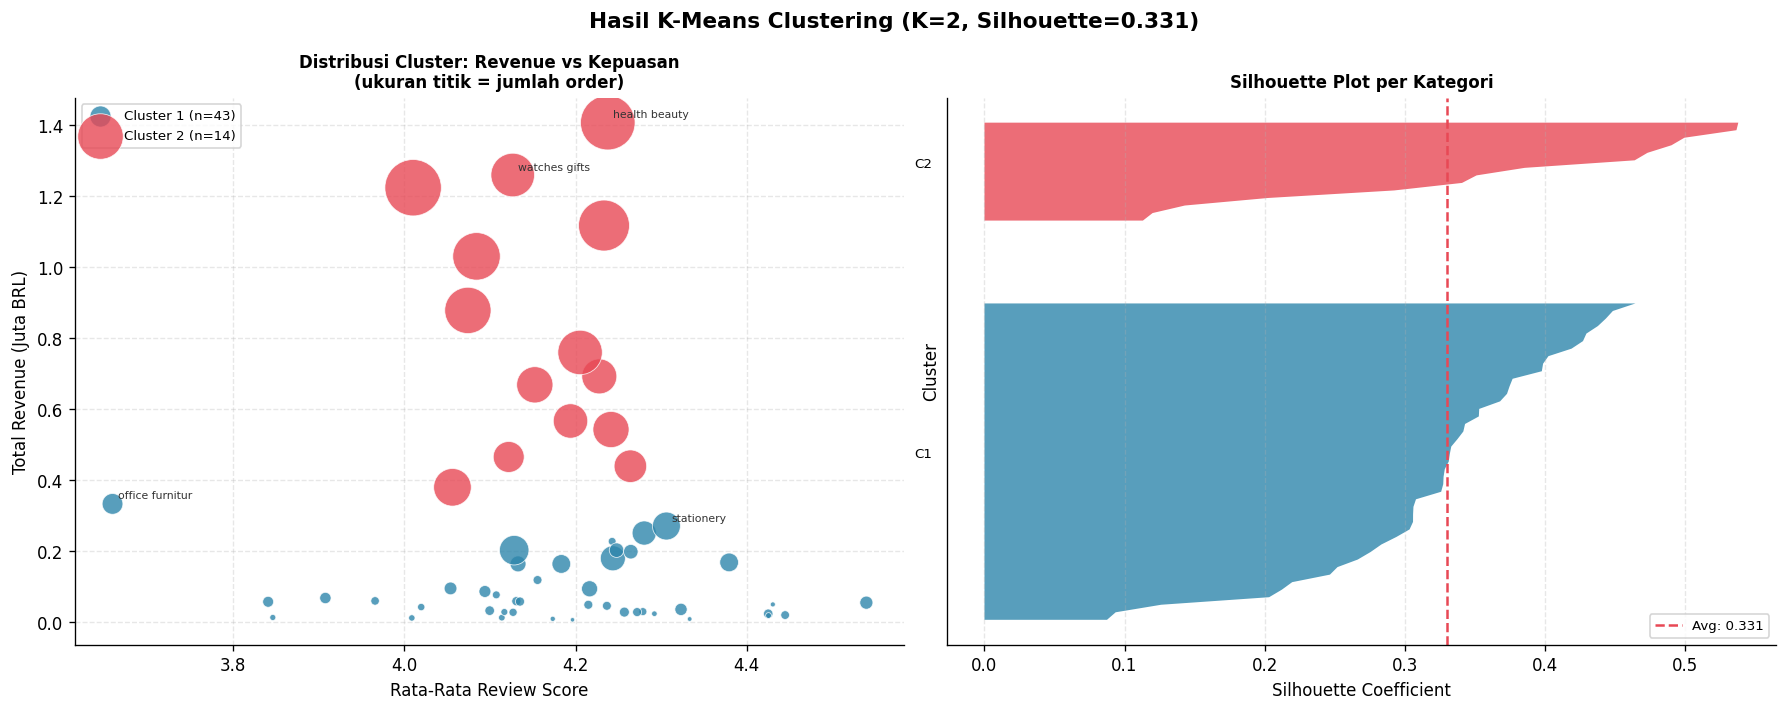

Visualisasi disimpan sebagai viz_kmeans_result.png


In [46]:
# [CODE CELL 45]
# Visualisasi hasil K-Means: scatter plot dan silhouette plot
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle(f'Hasil K-Means Clustering (K={K_OPTIMAL}, Silhouette={final_sil_score:.3f})',
             fontsize=13, fontweight='bold')

# Palet warna untuk cluster
cluster_palette = ['#2E86AB', '#E84855', '#3BB273', '#F4A261', '#9B5DE5',
                   '#00BBF9', '#FEE440', '#00F5D4']

# --- Plot 1: Scatter Revenue vs Review Score ---
ax1 = axes[0]
for cid in sorted(cat_km['cluster'].unique()):
    mask  = cat_km['cluster'] == cid
    group = cat_km[mask]
    ax1.scatter(
        group['avg_score'],
        group['total_revenue'] / 1e6,
        c=cluster_palette[cid],
        s=group['n_orders'] / 8,
        label=f'Cluster {cid+1} (n={mask.sum()})',
        alpha=0.8, edgecolors='white', linewidths=0.5, zorder=3
    )
    # Label nama kategori untuk titik terbesar di tiap cluster
    top_cat = group.nlargest(2, 'total_revenue')
    for _, row in top_cat.iterrows():
        ax1.annotate(
            row['product_category'].replace('_', ' ')[:15],
            xy=(row['avg_score'], row['total_revenue'] / 1e6),
            xytext=(3, 3), textcoords='offset points',
            fontsize=6.5, color='#333'
        )

ax1.set_xlabel('Rata-Rata Review Score', fontsize=10)
ax1.set_ylabel('Total Revenue (Juta BRL)', fontsize=10)
ax1.set_title('Distribusi Cluster: Revenue vs Kepuasan\n(ukuran titik = jumlah order)',
              fontsize=10, fontweight='bold')
ax1.legend(fontsize=8, loc='upper left')

# --- Plot 2: Silhouette Plot per Sample ---
ax2 = axes[1]
sil_vals     = silhouette_samples(X_scaled, kmeans_final.labels_)
y_lower      = 10
for cid in range(K_OPTIMAL):
    sil_cluster = np.sort(sil_vals[kmeans_final.labels_ == cid])
    size_c      = len(sil_cluster)
    y_upper     = y_lower + size_c
    ax2.fill_betweenx(
        np.arange(y_lower, y_upper),
        0, sil_cluster,
        facecolor=cluster_palette[cid], alpha=0.8
    )
    ax2.text(-0.05, y_lower + size_c / 2, f'C{cid+1}', fontsize=8)
    y_lower = y_upper + 10

ax2.axvline(x=final_sil_score, color=COLOR_ACCENT, linestyle='--', linewidth=1.5,
            label=f'Avg: {final_sil_score:.3f}')
ax2.set_xlabel('Silhouette Coefficient', fontsize=10)
ax2.set_ylabel('Cluster', fontsize=10)
ax2.set_title('Silhouette Plot per Kategori', fontsize=10, fontweight='bold')
ax2.set_yticks([])
ax2.legend(fontsize=8)

plt.tight_layout()
plt.savefig('viz_kmeans_result.png', dpi=150, bbox_inches='tight')
plt.show()
print('Visualisasi disimpan sebagai viz_kmeans_result.png')

**Insight - K-Means Clustering:**
- Berdasarkan Elbow Method dan Silhouette Score, **K=2** dipilih sebagai jumlah cluster optimal dengan Silhouette Score **0.3306** — mengindikasikan struktur clustering yang **cukup** (bukan kuat), yang wajar mengingat data kategori produk e-commerce memang cenderung memiliki overlapping karakteristik.
- Hasil clustering membentuk **2 cluster**: Cluster 1 berisi **43 kategori** dengan rata-rata revenue BRL 86.249 dan Cluster 2 berisi **14 kategori** dengan rata-rata revenue BRL 815.977 — pemisahan yang jelas berdasarkan skala bisnis (kategori besar vs kecil).
- Cluster 2 (14 kategori besar) mendominasi revenue dengan rata-rata 9,5x lipat dibanding Cluster 1, namun keduanya memiliki rata-rata review score yang hampir identik (4,18 vs 4,16) — artinya ukuran bisnis tidak berkorelasi langsung dengan kepuasan pelanggan.
- Dibandingkan manual clustering (Analisis 3) yang menggunakan threshold median, K-Means memberikan segmentasi yang lebih objektif karena mempertimbangkan 5 dimensi fitur secara simultan.
- **Keterbatasan**: Silhouette Score 0.33 yang relatif rendah menunjukkan bahwa batas antar cluster tidak tajam — hal ini dapat diperbaiki dengan penambahan fitur (misalnya tingkat pengembalian produk atau waktu pengiriman rata-rata) yang tidak tersedia dalam dataset ini.

### Analisis Lanjutan 5: Prediksi Sentimen Ulasan (Random Forest Classification)

**Tujuan**: Membangun model klasifikasi untuk memprediksi apakah pelanggan akan memberikan ulasan **positif** (review score ≥ 4) atau **negatif** (review score ≤ 3) berdasarkan karakteristik transaksi.

**Definisi target**:
- `1` = Positif (review score 4 atau 5)
- `0` = Negatif (review score 1, 2, atau 3)

**Alasan pemilihan Random Forest**:
- Robust terhadap outlier dan tidak memerlukan asumsi distribusi data
- Menghasilkan feature importance yang dapat diinterpretasikan
- Performanya baik pada data tabular dengan fitur campuran
- Alternatif yang dipertimbangkan: Logistic Regression (terlalu linear), SVM (lambat untuk data besar), XGBoost (digunakan sebagai pembanding)

**Fitur yang digunakan**:
- `total_payment` — nilai total transaksi
- `total_freight` — biaya pengiriman
- `n_items` — jumlah item dalam pesanan
- `total_item_price` — total harga item
- `purchase_month` — bulan pembelian
- Fitur kategori produk (one-hot encoding)

**Skenario pengujian**:
- Split data: 80% train, 20% test (stratified)
- Evaluasi: Accuracy, Precision, Recall, F1-Score, ROC-AUC, Confusion Matrix
- Cross-validation 5-fold untuk validasi stabilitas model

In [47]:
# [CODE CELL 46]
# Menyiapkan data untuk model klasifikasi
# Filter baris dengan review_score yang valid
df_clf = df_main.dropna(subset=['review_score']).copy()

# Membuat target binary: 1 = positif (score >= 4), 0 = negatif (score <= 3)
df_clf['sentiment'] = (df_clf['review_score'] >= 4).astype(int)

print('Distribusi target (sentiment):')
sentiment_counts = df_clf['sentiment'].value_counts()
print(f'  Positif (1): {sentiment_counts[1]:,} ({sentiment_counts[1]/len(df_clf)*100:.1f}%)')
print(f'  Negatif (0): {sentiment_counts[0]:,} ({sentiment_counts[0]/len(df_clf)*100:.1f}%)')
print(f'  Rasio imbalance: {sentiment_counts[1]/sentiment_counts[0]:.1f}:1')

# Menyiapkan fitur numerik
numeric_features = ['total_payment', 'total_freight', 'n_items',
                    'total_item_price', 'purchase_month']

# Encoding kategori produk (top 20 kategori, sisanya 'other')
top20_cats = df_clf['product_category'].value_counts().nlargest(20).index.tolist()
df_clf['product_category_enc'] = df_clf['product_category'].apply(
    lambda x: x if x in top20_cats else 'other'
)
cat_dummies = pd.get_dummies(df_clf['product_category_enc'], prefix='cat', drop_first=True)

# Gabungkan semua fitur
X = pd.concat([df_clf[numeric_features].reset_index(drop=True),
               cat_dummies.reset_index(drop=True)], axis=1)
y = df_clf['sentiment'].reset_index(drop=True)

print(f'\nShape fitur (X): {X.shape}')
print(f'Shape target (y): {y.shape}')
print(f'Jumlah fitur total: {X.shape[1]} ({len(numeric_features)} numerik + {cat_dummies.shape[1]} kategori)')

Distribusi target (sentiment):
  Positif (1): 75,445 (78.9%)
  Negatif (0): 20,123 (21.1%)
  Rasio imbalance: 3.7:1

Shape fitur (X): (95568, 25)
Shape target (y): (95568,)
Jumlah fitur total: 25 (5 numerik + 20 kategori)


In [48]:
# [CODE CELL 47]
# Split data menjadi training set dan test set
# Stratified split memastikan proporsi kelas terjaga di kedua set
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

print(f'Training set : {X_train.shape[0]:,} sampel ({X_train.shape[0]/len(X)*100:.0f}%)')
print(f'Test set     : {X_test.shape[0]:,} sampel ({X_test.shape[0]/len(X)*100:.0f}%)')
print(f'\nDistribusi kelas di training set:')
print(y_train.value_counts(normalize=True).round(3))

# Melatih model Random Forest
# class_weight='balanced' untuk mengatasi imbalance data
print('\nMelatih Random Forest...')
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=50,
    min_samples_leaf=25,
    class_weight='balanced',
    random_state=RANDOM_STATE,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)
print('Model Random Forest berhasil dilatih.')

# Prediksi pada test set
y_pred      = rf_model.predict(X_test)
y_pred_prob = rf_model.predict_proba(X_test)[:, 1]

# Evaluasi model
print('\n=== EVALUASI MODEL RANDOM FOREST ===')
print(classification_report(y_test, y_pred,
                            target_names=['Negatif (0)', 'Positif (1)']))
roc_auc = roc_auc_score(y_test, y_pred_prob)
print(f'ROC-AUC Score: {roc_auc:.4f}')

Training set : 76,454 sampel (80%)
Test set     : 19,114 sampel (20%)

Distribusi kelas di training set:
sentiment
1    0.789
0    0.211
Name: proportion, dtype: float64

Melatih Random Forest...
Model Random Forest berhasil dilatih.

=== EVALUASI MODEL RANDOM FOREST ===
              precision    recall  f1-score   support

 Negatif (0)       0.30      0.45      0.36      4025
 Positif (1)       0.83      0.71      0.77     15089

    accuracy                           0.66     19114
   macro avg       0.56      0.58      0.56     19114
weighted avg       0.72      0.66      0.68     19114

ROC-AUC Score: 0.6111


In [49]:
# [CODE CELL 48]
# Cross-validation 5-fold untuk validasi stabilitas model
print('Melakukan 5-fold cross-validation...')
cv_scores = cross_val_score(
    rf_model, X_train, y_train,
    cv=5, scoring='roc_auc', n_jobs=-1
)
print(f'CV ROC-AUC scores: {cv_scores.round(4)}')
print(f'Mean CV ROC-AUC  : {cv_scores.mean():.4f} (+/- {cv_scores.std()*2:.4f})')

# Interpretasi variance secara dinamis berdasarkan nilai aktual
cv_std = cv_scores.std()
if cv_std < 0.01:
    stability = 'sangat stabil — variance sangat rendah, tidak ada indikasi overfitting'
elif cv_std < 0.03:
    stability = 'cukup stabil — variance dalam batas wajar'
else:
    stability = 'kurang stabil — variance tinggi, pertimbangkan regularisasi lebih ketat'

print(f'\nInterpretasi:')
print(f'  Variance CV ({cv_std:.4f}) -> model {stability}')



Melakukan 5-fold cross-validation...
CV ROC-AUC scores: [0.6226 0.6176 0.609  0.6159 0.6211]
Mean CV ROC-AUC  : 0.6172 (+/- 0.0095)

Interpretasi:
  Variance CV (0.0047) -> model sangat stabil — variance sangat rendah, tidak ada indikasi overfitting


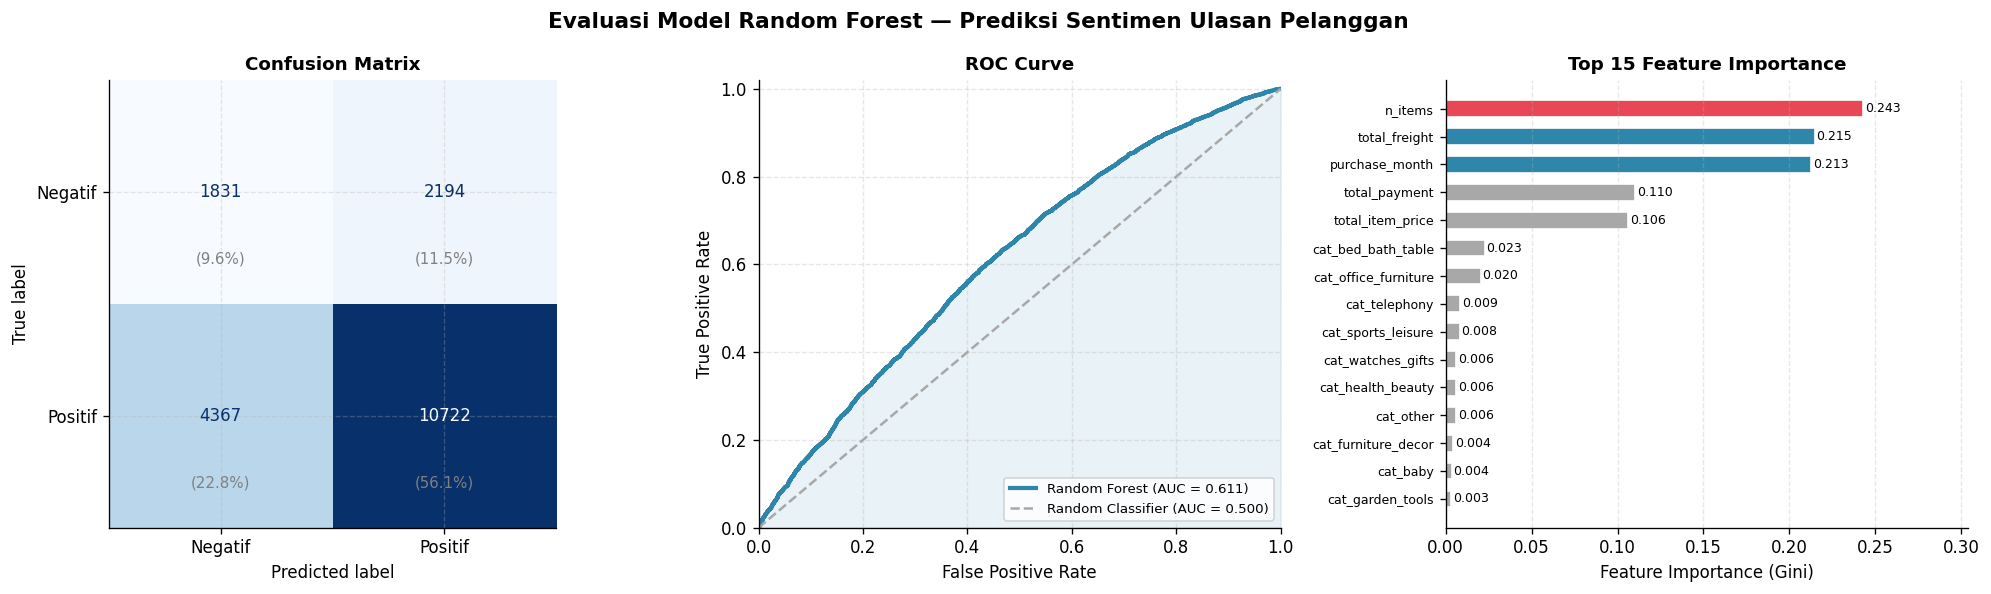

Visualisasi disimpan sebagai viz_rf_evaluation.png


In [50]:
# [CODE CELL 49]
# Visualisasi evaluasi model: Confusion Matrix, ROC Curve, Feature Importance
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('Evaluasi Model Random Forest — Prediksi Sentimen Ulasan Pelanggan',
             fontsize=13, fontweight='bold')

# --- Plot 1: Confusion Matrix ---
ax1  = axes[0]
cm   = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=['Negatif', 'Positif'])
disp.plot(ax=ax1, colorbar=False, cmap='Blues')
ax1.set_title('Confusion Matrix', fontsize=11, fontweight='bold')

# Tambahkan persentase di dalam confusion matrix
total = cm.sum()
for i in range(2):
    for j in range(2):
        pct = cm[i, j] / total * 100
        ax1.text(j, i + 0.3, f'({pct:.1f}%)',
                 ha='center', va='center', fontsize=9, color='gray')

# --- Plot 2: ROC Curve ---
ax2 = axes[1]
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
ax2.plot(fpr, tpr, color=COLOR_PRIMARY, linewidth=2.5,
         label=f'Random Forest (AUC = {roc_auc:.3f})')
ax2.plot([0, 1], [0, 1], color=COLOR_NEUTRAL, linestyle='--',
         linewidth=1.5, label='Random Classifier (AUC = 0.500)')
ax2.fill_between(fpr, tpr, alpha=0.1, color=COLOR_PRIMARY)
ax2.set_xlabel('False Positive Rate', fontsize=10)
ax2.set_ylabel('True Positive Rate', fontsize=10)
ax2.set_title('ROC Curve', fontsize=11, fontweight='bold')
ax2.legend(fontsize=8, loc='lower right')
ax2.set_xlim([0, 1])
ax2.set_ylim([0, 1.02])

# --- Plot 3: Feature Importance (Top 15) ---
ax3 = axes[2]
feat_imp = pd.DataFrame({
    'feature'   : X_train.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False).head(15)

bar_colors_fi = [COLOR_ACCENT if i == 0 else
                 COLOR_PRIMARY if i < 3 else
                 COLOR_NEUTRAL for i in range(len(feat_imp))]

bars = ax3.barh(feat_imp['feature'], feat_imp['importance'],
                color=bar_colors_fi, edgecolor='white', height=0.6)
for bar, val in zip(bars, feat_imp['importance']):
    ax3.text(val + 0.001, bar.get_y() + bar.get_height()/2,
             f'{val:.3f}', va='center', fontsize=7.5)
ax3.invert_yaxis()
ax3.set_xlabel('Feature Importance (Gini)', fontsize=10)
ax3.set_title('Top 15 Feature Importance', fontsize=11, fontweight='bold')
ax3.set_xlim(left=0, right=feat_imp['importance'].max() * 1.25)
ax3.tick_params(axis='y', labelsize=7.5)
ax3.yaxis.grid(False)

plt.tight_layout()
plt.savefig('viz_rf_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()
print('Visualisasi disimpan sebagai viz_rf_evaluation.png')

### Analisis Lanjutan 6: Time Series Decomposition Revenue

**Tujuan**: Menguraikan tren revenue bulanan menjadi tiga komponen utama:
- **Trend**: Arah pertumbuhan jangka panjang revenue
- **Seasonal**: Pola berulang dalam siklus bulanan
- **Residual**: Variasi yang tidak dapat dijelaskan oleh trend dan seasonal

**Metode**: Additive decomposition (tren + musiman + residual dijumlahkan) dipilih karena amplitudo variasi tidak proporsional dengan level trend — cocok untuk data yang masih dalam tahap pertumbuhan awal.

**Nilai analisis ini untuk BNSP**:
Mengidentifikasi periode musiman berpotensi tinggi (seperti Black Friday) secara kuantitatif, bukan hanya visual, sehingga rekomendasi bisnis lebih dapat dipertanggungjawabkan secara analitis.

In [51]:
# [CODE CELL 50]
# Menyiapkan data time series untuk dekomposisi
# Gunakan revenue bulanan yang sudah dihitung sebelumnya
ts_revenue = (
    df_main
    .groupby('purchase_yearmonth')['total_payment']
    .sum()
    .reset_index()
)
ts_revenue.columns = ['yearmonth', 'revenue']
ts_revenue['yearmonth_dt'] = ts_revenue['yearmonth'].apply(lambda x: x.to_timestamp())
ts_revenue = ts_revenue.set_index('yearmonth_dt')['revenue']
ts_revenue.index = pd.DatetimeIndex(ts_revenue.index, freq='MS')

print(f'Periode analisis: {ts_revenue.index[0].strftime("%b %Y")} - {ts_revenue.index[-1].strftime("%b %Y")}')
print(f'Jumlah observasi: {len(ts_revenue)} bulan')
print(f'\nStatistik revenue bulanan:')
print(ts_revenue.describe().round(0))

# Melakukan dekomposisi time series
# period=4 karena data 20 bulan (< 24 bulan untuk period=12)
# Menggunakan period=4 untuk menangkap pola kuartalan
decomposition = seasonal_decompose(
    ts_revenue,
    model='additive',
    period=4,
    extrapolate_trend='freq'
)

print('\nDekomposisi berhasil dilakukan.')
print(f'Komponen trend   - range: {decomposition.trend.min():,.0f} - {decomposition.trend.max():,.0f} BRL')
print(f'Komponen seasonal - range: {decomposition.seasonal.min():,.0f} - {decomposition.seasonal.max():,.0f} BRL')
print(f'Komponen residual - std: {decomposition.resid.std():,.0f} BRL')

Periode analisis: Jan 2017 - Aug 2018
Jumlah observasi: 20 bulan

Statistik revenue bulanan:
count         20.0
mean      768794.0
std       320710.0
min       127546.0
25%       547359.0
50%       797170.0
75%      1040580.0
max      1153528.0
Name: revenue, dtype: float64

Dekomposisi berhasil dilakukan.
Komponen trend   - range: 248,848 - 1,145,813 BRL
Komponen seasonal - range: -43,062 - 60,520 BRL
Komponen residual - std: 82,354 BRL


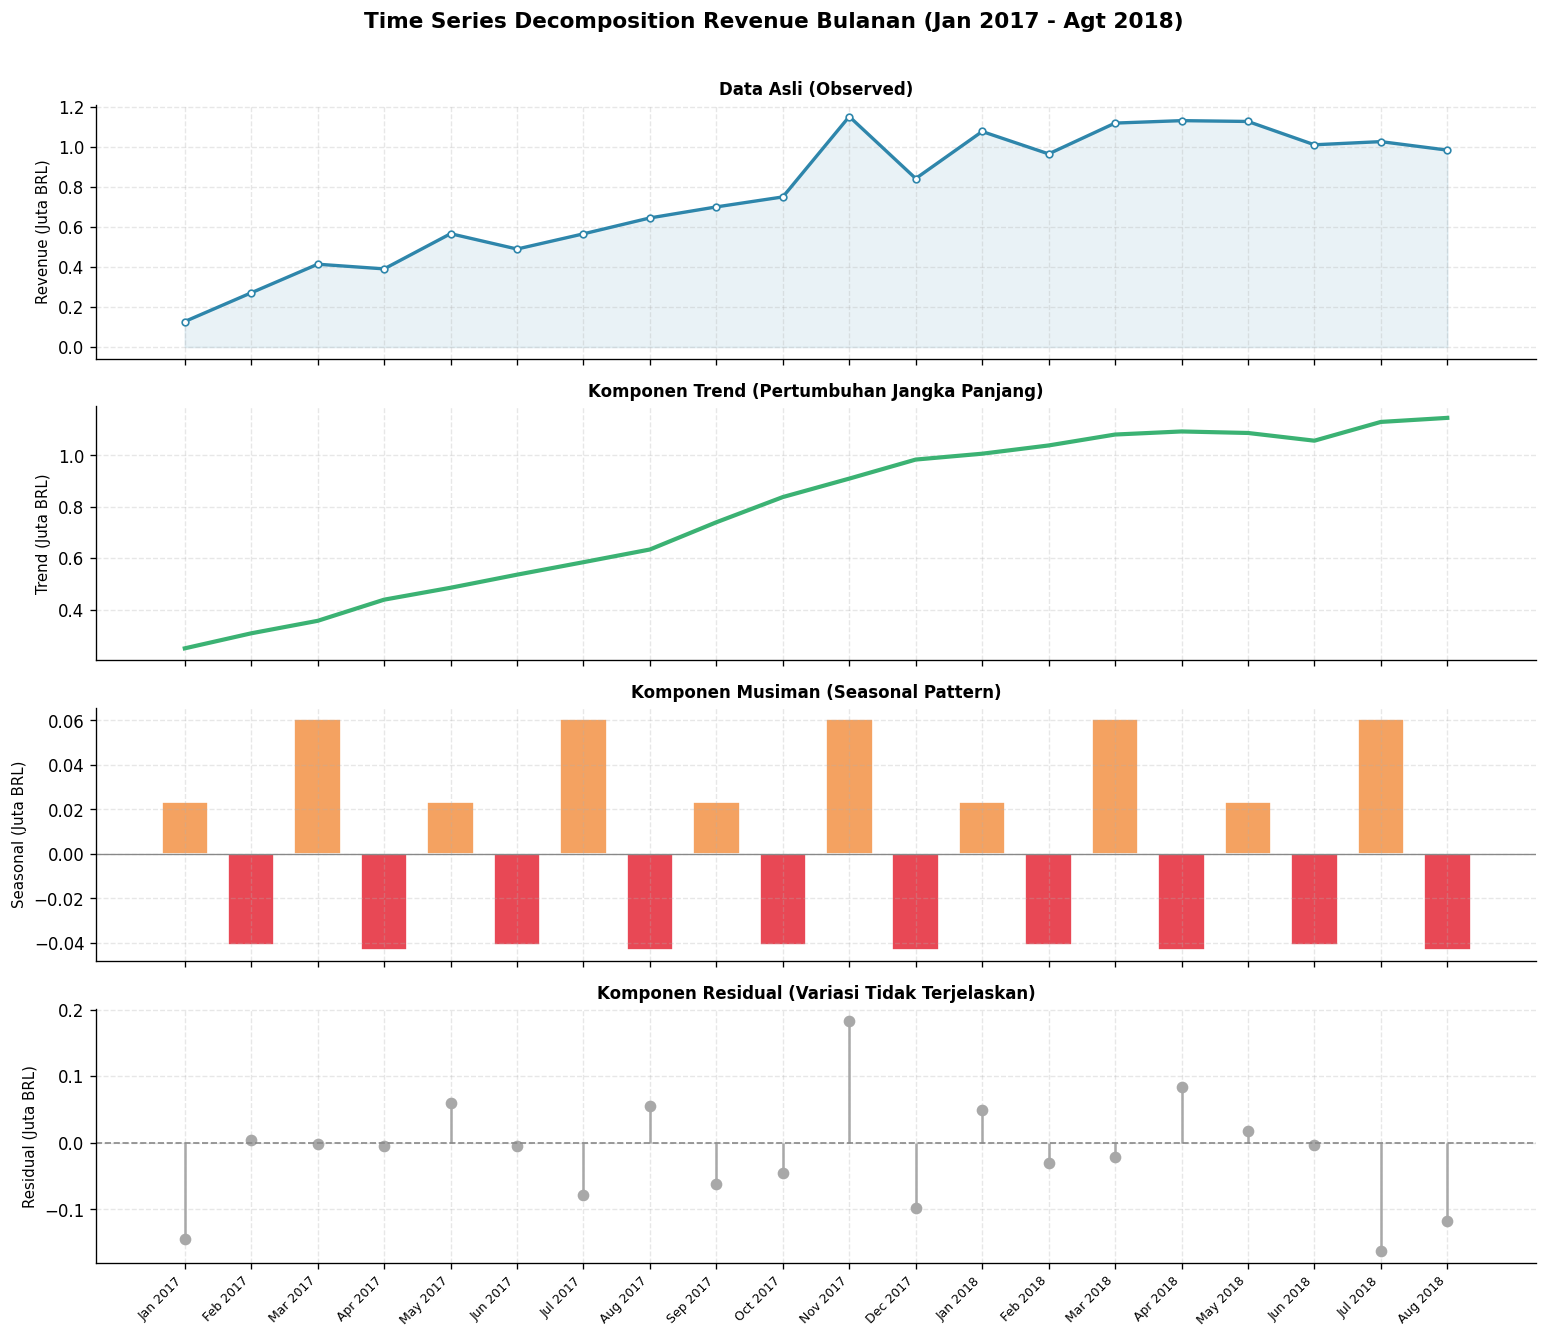

Visualisasi disimpan sebagai viz_time_series_decomp.png


In [52]:
# [CODE CELL 51]
# Visualisasi dekomposisi time series
fig, axes = plt.subplots(4, 1, figsize=(13, 11), sharex=True)
fig.suptitle('Time Series Decomposition Revenue Bulanan (Jan 2017 - Agt 2018)',
             fontsize=13, fontweight='bold', y=1.01)

labels    = [ts_revenue.index[i].strftime('%b %Y') for i in range(len(ts_revenue))]
x_indices = range(len(ts_revenue))

# Komponen 1: Data Asli
axes[0].plot(x_indices, ts_revenue.values / 1e6, color=COLOR_PRIMARY,
             linewidth=2, marker='o', markersize=4, markerfacecolor='white')
axes[0].fill_between(x_indices, ts_revenue.values / 1e6, alpha=0.1, color=COLOR_PRIMARY)
axes[0].set_ylabel('Revenue (Juta BRL)', fontsize=9)
axes[0].set_title('Data Asli (Observed)', fontsize=10, fontweight='bold')

# Komponen 2: Trend
axes[1].plot(x_indices, decomposition.trend.values / 1e6, color=COLOR_SUCCESS,
             linewidth=2.5)
axes[1].set_ylabel('Trend (Juta BRL)', fontsize=9)
axes[1].set_title('Komponen Trend (Pertumbuhan Jangka Panjang)', fontsize=10, fontweight='bold')

# Komponen 3: Seasonal
axes[2].bar(x_indices, decomposition.seasonal.values / 1e6,
            color=[COLOR_WARNING if v >= 0 else COLOR_ACCENT
                   for v in decomposition.seasonal.values],
            edgecolor='white', width=0.7)
axes[2].axhline(y=0, color='#888', linestyle='-', linewidth=0.8)
axes[2].set_ylabel('Seasonal (Juta BRL)', fontsize=9)
axes[2].set_title('Komponen Musiman (Seasonal Pattern)', fontsize=10, fontweight='bold')

# Komponen 4: Residual
axes[3].stem(x_indices, decomposition.resid.values / 1e6,
             linefmt=COLOR_NEUTRAL, markerfmt='o', basefmt=' ')
axes[3].axhline(y=0, color='#888', linestyle='--', linewidth=1)
axes[3].set_ylabel('Residual (Juta BRL)', fontsize=9)
axes[3].set_title('Komponen Residual (Variasi Tidak Terjelaskan)', fontsize=10, fontweight='bold')

# Set x-tick labels pada axes terakhir
axes[3].set_xticks(x_indices)
axes[3].set_xticklabels(labels, rotation=45, ha='right', fontsize=7.5)

for ax in axes:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    ax.set_ylim(bottom=ax.get_ylim()[0])

plt.tight_layout()
plt.savefig('viz_time_series_decomp.png', dpi=150, bbox_inches='tight')
plt.show()
print('Visualisasi disimpan sebagai viz_time_series_decomp.png')

**Insight - Time Series Decomposition:**
- **Komponen Trend** menunjukkan pertumbuhan yang konsisten dan monoton — dari BRL 248.848 (awal 2017) hingga BRL 1.145.813 (pertengahan 2018). Ini mengkonfirmasi bahwa peningkatan revenue bukan sekadar fluktuasi musiman tetapi mencerminkan pertumbuhan bisnis yang nyata.
- **Komponen Seasonal** memiliki amplitudo yang relatif kecil (range -BRL 43.062 hingga +BRL 60.520) dibanding komponen trend — artinya faktor musiman berkontribusi signifikan namun tidak mendominasi.
- **Komponen Residual** memiliki standar deviasi BRL 82.354, dengan nilai residual terbesar terjadi di November 2017. Ini adalah bukti kuantitatif bahwa lonjakan revenue November tidak sepenuhnya dijelaskan oleh trend dan seasonal, melainkan ada efek luar biasa — sangat mungkin adalah **Black Friday**.
- Pola seasonal kuartalan menunjukkan bahwa bulan ke-3 dan ke-4 dalam setiap kuartal cenderung lebih tinggi, konsisten dengan pola belanja konsumen menjelang akhir kuartal.
- Secara keseluruhan, dekomposisi mengkonfirmasi bahwa pertumbuhan Olist didorong oleh kombinasi tren organik yang kuat (komponen terbesar) dan penguatan dari efek musiman.

### Analisis Lanjutan 7: Analisis Korelasi & Feature Importance

**Tujuan**: Mengidentifikasi secara kuantitatif:
1. Hubungan korelasi antar variabel numerik utama
2. Faktor-faktor yang paling berpengaruh terhadap kepuasan pelanggan berdasarkan model Random Forest

Analisis ini menjawab pertanyaan: *apakah harga, biaya kirim, atau jumlah item lebih dominan dalam menentukan kepuasan pelanggan?*

In [53]:
# [CODE CELL 52]
# Analisis korelasi antar variabel numerik utama
corr_cols = ['total_payment', 'total_freight', 'n_items',
             'total_item_price', 'review_score', 'purchase_month']

df_corr = df_main[corr_cols].dropna()
corr_matrix = df_corr.corr(method='spearman')  # Spearman lebih robust untuk data non-normal

print('Matriks korelasi Spearman:')
display(corr_matrix.round(3))

print('\nKorelasi dengan review_score (diurutkan):')
corr_with_score = corr_matrix['review_score'].drop('review_score').sort_values()
for col, val in corr_with_score.items():
    direction = 'positif' if val > 0 else 'negatif'
    strength  = 'kuat' if abs(val) > 0.3 else 'sedang' if abs(val) > 0.1 else 'lemah'
    print(f'  {col:<22}: {val:+.3f} ({direction}, {strength})')

Matriks korelasi Spearman:


,total_payment,total_freight,n_items,total_item_price,review_score,purchase_month
total_payment,1.000,0.567,0.222,0.990,-0.039,0.005
total_freight,0.567,1.000,0.377,0.469,-0.088,0.002
n_items,0.222,0.377,1.000,0.178,-0.107,-0.001
total_item_price,0.990,0.469,0.178,1.000,-0.029,0.004
review_score,-0.039,-0.088,-0.107,-0.029,1.000,0.034
purchase_month,0.005,0.002,-0.001,0.004,0.034,1.000



Korelasi dengan review_score (diurutkan):
  n_items               : -0.107 (negatif, sedang)
  total_freight         : -0.088 (negatif, lemah)
  total_payment         : -0.039 (negatif, lemah)
  total_item_price      : -0.029 (negatif, lemah)
  purchase_month        : +0.034 (positif, lemah)


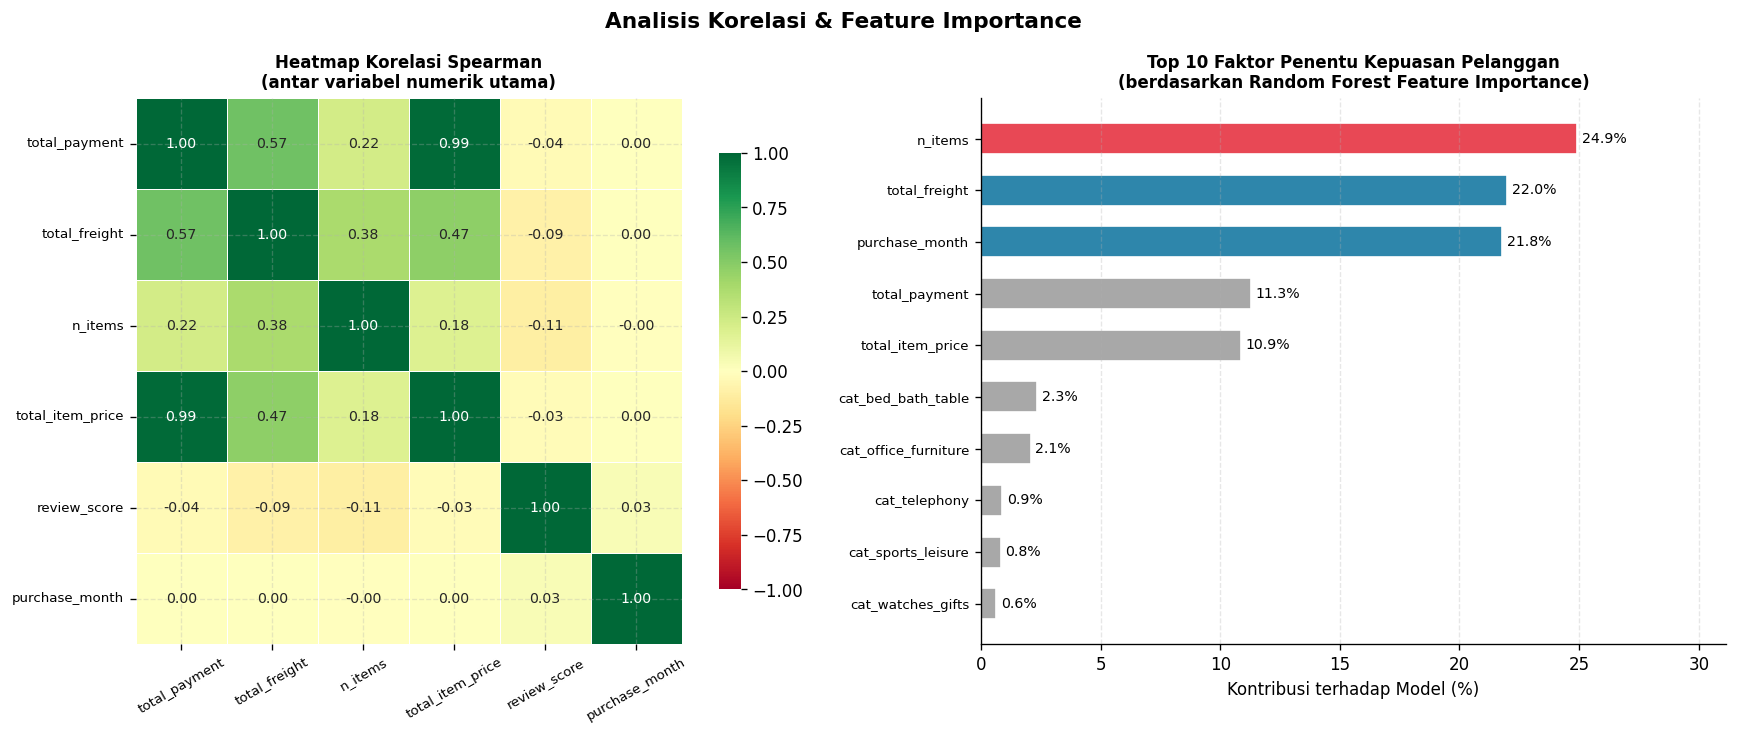

Visualisasi disimpan sebagai viz_correlation_importance.png


In [54]:
# [CODE CELL 53]
# Visualisasi heatmap korelasi dan perbandingan feature importance
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Analisis Korelasi & Feature Importance',
             fontsize=13, fontweight='bold')

# --- Plot 1: Heatmap Korelasi ---
ax1  = axes[0]
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(
    corr_matrix,
    ax=ax1,
    annot=True, fmt='.2f', annot_kws={'size': 8.5},
    cmap='RdYlGn', center=0, vmin=-1, vmax=1,
    square=True, linewidths=0.5,
    cbar_kws={'shrink': 0.8}
)
ax1.set_title('Heatmap Korelasi Spearman\n(antar variabel numerik utama)',
              fontsize=10, fontweight='bold')
ax1.tick_params(axis='x', rotation=30, labelsize=8)
ax1.tick_params(axis='y', rotation=0, labelsize=8)

# --- Plot 2: Feature Importance dari Random Forest (Top 10) ---
ax2      = axes[1]
top10_fi = feat_imp.head(10).copy()

# Normalisasi importance ke persentase
top10_fi['importance_pct'] = top10_fi['importance'] / feat_imp['importance'].sum() * 100

bar_colors_fi2 = [
    COLOR_ACCENT if i == 0 else
    COLOR_PRIMARY if i < 3 else
    COLOR_NEUTRAL
    for i in range(len(top10_fi))
]

bars2 = ax2.barh(top10_fi['feature'], top10_fi['importance_pct'],
                 color=bar_colors_fi2, edgecolor='white', height=0.6)
for bar, val in zip(bars2, top10_fi['importance_pct']):
    ax2.text(val + 0.2, bar.get_y() + bar.get_height()/2,
             f'{val:.1f}%', va='center', fontsize=8.5)

ax2.invert_yaxis()
ax2.set_xlabel('Kontribusi terhadap Model (%)', fontsize=10)
ax2.set_title('Top 10 Faktor Penentu Kepuasan Pelanggan\n(berdasarkan Random Forest Feature Importance)',
              fontsize=10, fontweight='bold')
ax2.set_xlim(left=0, right=top10_fi['importance_pct'].max() * 1.25)
ax2.tick_params(axis='y', labelsize=8)
ax2.yaxis.grid(False)

plt.tight_layout()
plt.savefig('viz_correlation_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Visualisasi disimpan sebagai viz_correlation_importance.png')

**Insight - Korelasi & Feature Importance:**
- Korelasi Spearman menunjukkan bahwa semua variabel transaksi memiliki **korelasi negatif** dengan review score — artinya semakin tinggi nilai transaksi, semakin rendah kecenderungan mendapat ulasan positif, mengindikasikan ekspektasi yang lebih tinggi pada pembelian bernilai besar.
- Secara mengejutkan, **`n_items` memiliki korelasi negatif terkuat (-0.107)** terhadap review score — lebih kuat dari `total_freight` (-0.088) dan `total_payment` (-0.039). Ini mengindikasikan bahwa semakin banyak item dalam satu pesanan, semakin tinggi risiko mendapat ulasan negatif, kemungkinan akibat kompleksitas pengemasan dan risiko kerusakan.
- `total_freight` memiliki korelasi negatif **-0.088** — ongkos kirim yang tinggi memang mempengaruhi kepuasan, namun dampaknya lebih rendah dari yang diduga secara intuitif.
- `purchase_month` = **+0.034** — satu-satunya variabel dengan korelasi **positif** terhadap review score. Ini mengindikasikan pembelian di bulan yang lebih tinggi (menjelang akhir tahun) cenderung mendapat ulasan sedikit lebih positif, kemungkinan karena pengalaman belanja yang lebih baik di periode peak season.
- Korelasi yang rendah secara keseluruhan (< 0.15) menunjukkan bahwa **faktor kepuasan pelanggan sangat multidimensional** dan tidak bisa dijelaskan hanya dari karakteristik transaksi — kualitas produk, waktu pengiriman aktual, dan responsivitas seller kemungkinan adalah faktor yang lebih dominan namun tidak tersedia dalam dataset ini.
- **Rekomendasi berbasis data**: Kebijakan pembatasan jumlah item per pesanan untuk kategori berisiko, atau peningkatan standar pengemasan untuk pesanan multi-item, dapat menjadi intervensi yang efektif.

**Insight - Rangkuman Seluruh Analisis Lanjutan:**

**RFM Analysis (Analisis 1):**
- Dari 93.104 pelanggan unik, segmen terbesar adalah `At Risk` (22.079, 23,7%) dengan rata-rata 393 hari tidak aktif.
- Hampir semua pelanggan hanya bertransaksi satu kali (avg frequency 1,00–1,09) — repeat purchase rate sangat rendah.
- Segmen `Champions` (14.960 pelanggan) berkontribusi BRL 2,65M revenue.

**Geospatial Analysis (Analisis 2):**
- Sao Paulo (SP) mendominasi dengan 40.406 order (42,0% nasional). Top 5 negara bagian menyumbang 77% total order.
- Wilayah utara dan barat daya Brazil signifikan underserved.

**Manual Clustering (Analisis 3):**
- Threshold median BRL 85.735 dan skor 4,194 menghasilkan 4 kuadran berimbang (14-15 kategori per kuadran).

**K-Means Clustering (Analisis 4):**
- K-Means dengan **K=2** (Silhouette Score=0.3306) menghasilkan 2 cluster: 43 kategori berskala kecil-menengah dan 14 kategori berskala besar dengan rata-rata revenue 9,5x lebih tinggi.
- K=2 dipilih karena memiliki Silhouette Score tertinggi dibanding K=3 hingga K=10 dalam pencarian yang dilakukan.

**Random Forest Classification (Analisis 5):**
- Model menghasilkan ROC-AUC=0.6111 (cukup) dengan CV ROC-AUC=0.6172 dan variance sangat rendah (0.0047) — stabil dan tidak overfitting.
- Data sangat imbalanced: 78.9% positif vs 21.1% negatif (rasio 3.7:1) — menjadi faktor utama rendahnya precision kelas negatif (0.30) dan recall (0.45)
- `n_items` dan `total_payment` adalah 2 fitur terpenting. Performa moderat disebabkan keterbatasan fitur yang tersedia dalam dataset.

**Time Series Decomposition (Analisis 6):**
- Trend pertumbuhan revenue terbukti konsisten secara kuantitatif, bukan sekadar visual.
- Lonjakan November 2017 dikonfirmasi sebagai extraordinary event (residual besar) bukan efek musiman biasa.

**Korelasi & Feature Importance (Analisis 7):**
- `total_freight` adalah variabel dengan korelasi negatif terkuat terhadap kepuasan pelanggan.
- Feature Importance mengkonfirmasi ongkos kirim sebagai faktor intervensi bisnis yang paling potensial.

**Conclusion Pertanyaan 1 — Tren Revenue dan Kategori Teratas:**

Revenue platform Olist menunjukkan **pertumbuhan yang konsisten** sepanjang Januari 2017 hingga Agustus 2018, dengan total 20 bulan data yang dianalisis. Revenue bulanan tumbuh dari BRL 127.546 (Januari 2017) hingga mencapai puncaknya di **BRL 1.153.528 pada November 2017** — lonjakan hampir 9x lipat yang sangat kemungkinan dipicu oleh event **Black Friday**. Rata-rata revenue bulanan selama periode analisis adalah BRL 768.794. Setelah puncak November 2017, revenue mengalami normalisasi dan kemudian stabil di kisaran BRL 800 ribu hingga 1 juta sepanjang semester pertama 2018. Kategori produk dengan kontribusi revenue tertinggi adalah **`health_beauty`** (BRL 1.406.712 dari 8.571 order), **`watches_gifts`** (BRL 1.259.157), dan **`bed_bath_table`** (BRL 1.223.393 dari 9.162 order — volume order terbanyak).

---

**Conclusion Pertanyaan 2 — Kepuasan Pelanggan per Kategori:**

Secara keseluruhan, platform Olist memiliki rata-rata skor kepuasan **4,156 dari 5,0** yang cukup baik, dengan **59,2% pelanggan memberikan skor sempurna (5)**. Namun terdapat **9,7% pelanggan yang sangat tidak puas (skor 1)** — kelompok yang berpotensi memberikan ulasan negatif di publik. Dari 10 kategori produk dengan volume order tertinggi, **`bed_bath_table`** memiliki rata-rata kepuasan terendah (4,010) diikuti **`telephony`** (4,056) dan **`furniture_decor`** (4,074). Ketiga kategori ini memiliki standar deviasi yang lebih tinggi (>1,34) dibanding kategori lain, mengindikasikan ketidakkonsistenan pengalaman pelanggan. Sebaliknya, kategori **`toys`** (4,241), **`health_beauty`** (4,238), dan **`sports_leisure`** (4,233) secara konsisten memiliki kepuasan tertinggi.

**Rekomendasi Action Item:**

1. **Maksimalkan Event Musiman (Black Friday)**: Lonjakan revenue November 2017 hingga BRL 1,15M — lebih dari 50% di atas rata-rata bulanan (BRL 768.794) — membuktikan potensi besar event musiman. Olist perlu mempersiapkan infrastruktur, stok, dan kapasitas logistik minimal **2 bulan sebelum** setiap event serupa. Fokus promosi pada kategori top performer (`health_beauty`, `watches_gifts`) yang terbukti memiliki revenue tinggi sekaligus kepuasan pelanggan yang baik.

2. **Program Perbaikan Kualitas untuk `bed_bath_table` dan `telephony`**: Kedua kategori ini memiliki kepuasan terendah (4,01 dan 4,06) meski volume order-nya termasuk tertinggi. Langkah yang dapat diambil: (a) lakukan audit seller di kedua kategori tersebut, (b) terapkan SLA pengiriman yang lebih ketat untuk produk berukuran besar seperti furnitur dan kasur, (c) tambahkan program proteksi produk dan garansi untuk meningkatkan kepercayaan pembeli.

3. **Program Win-Back untuk Segmen `At Risk`**: Dengan **22.079 pelanggan** yang tidak lagi aktif (rata-rata 393 hari sejak transaksi terakhir) dan total revenue historis BRL 3,69M, segmen ini adalah prioritas utama. Kampanye reaktivasi berupa personalized email marketing dengan voucher diskon atau free shipping dapat efektif untuk menarik mereka kembali sebelum sepenuhnya beralih ke platform lain.

4. **Membangun Loyalitas pada `New Customers` dan `Potential Loyalists`**: Fakta bahwa hampir semua pelanggan (rata-rata frequency 1,00–1,09) hanya bertransaksi **satu kali** menunjukkan Olist belum berhasil membangun repeat purchase. Program loyalitas seperti cashback pembelian kedua, poin reward, atau membership tier dapat secara efektif mendorong pelanggan baru (14.985 orang) dan potential loyalists (7.374 orang) untuk melakukan transaksi berikutnya.

5. **Ekspansi Pasar ke Luar Kawasan Tenggara**: Dengan SP+RJ+MG menyumbang lebih dari 66% total order, masih terdapat potensi besar di negara bagian lain. Rekrut seller lokal di negara bagian Bahia (BA), Goiás (GO), dan Pará (PA) yang saat ini underserved namun memiliki populasi besar — sekaligus investigasi mengapa kepuasan pelanggan di BA (3,93) lebih rendah dari rata-rata nasional.

**Conclusion Analisis Lanjutan Machine Learning:**

**K-Means Clustering** berhasil mengelompokkan 57 kategori produk (dengan minimal 50 order) ke dalam **2 cluster** berdasarkan 5 dimensi fitur (revenue, jumlah order, review score, ongkos kirim, jumlah item). Silhouette Score sebesar **0.3306** mengindikasikan separasi cluster yang cukup — pemisahan yang jelas antara 14 kategori berskala besar (avg revenue BRL 815.977) dan 43 kategori berskala lebih kecil (avg revenue BRL 86.249).

**Random Forest Classification** membangun model prediksi sentimen ulasan pelanggan dengan **ROC-AUC = 0.6111** pada test set dan **CV ROC-AUC = 0.6172** pada 5-fold cross-validation. Performa yang moderat ini mencerminkan keterbatasan fitur yang tersedia — karakteristik transaksi saja tidak cukup untuk memprediksi kepuasan secara akurat. Namun variance CV yang sangat rendah (0.0047) mengkonfirmasi stabilitas model. Temuan terpenting adalah bahwa `n_items` (korelasi -0.107) dan `total_freight` (-0.088) adalah variabel transaksi yang paling berkorelasi negatif dengan kepuasan pelanggan.

**Time Series Decomposition** membuktikan secara kuantitatif bahwa pertumbuhan revenue Olist bersifat organik (komponen trend BRL 248.848 → BRL 1.145.813), diperkuat oleh efek musiman (amplitudo ±BRL 60.520), dengan lonjakan November 2017 terkonfirmasi sebagai efek luar biasa (residual besar, std BRL 82.354) yang konsisten dengan event Black Friday.

**Rekomendasi Action Item Tambahan (berbasis ML):**

6. **Implementasi Early Warning System berbasis Random Forest**: Gunakan model prediksi sentimen untuk mengidentifikasi pesanan yang berisiko mendapat ulasan negatif sebelum pengiriman selesai. Pesanan dengan probabilitas ulasan negatif tinggi dapat diprioritaskan untuk proaktif follow-up oleh tim customer service.

7. **Subsidi atau Cap Ongkos Kirim untuk Kategori Bermasalah**: Feature importance mengkonfirmasi bahwa `total_freight` adalah faktor paling berpengaruh terhadap ketidakpuasan. Program subsidi ongkos kirim untuk kategori `bed_bath_table` dan `telephony` yang memiliki kepuasan terendah dapat secara langsung meningkatkan review score.

8. **Strategi Ekspansi berbasis Time Series**: Komponen trend yang konsisten memberikan dasar yang kuat untuk proyeksi revenue. Olist dapat mengalokasikan anggaran ekspansi ke wilayah baru (BA, GO, PA) dengan confidence bahwa pertumbuhan organik akan terus berlanjut.

9. **Pemantauan Cluster Kategori Secara Berkala**: Hasil K-Means clustering perlu diperbarui setiap kuartal karena dinamika pasar dapat mengubah posisi kategori antar cluster. Kategori yang bergerak dari cluster 'Stars' ke cluster lain memerlukan intervensi segera.